# Baseline Models Reproducing Paper Experiments

# 1. Import Libraries & Load Dataset

In [1]:
# Install required libraries
!pip install xgboost pytorch-tabnet scikit-fuzzy seaborn

# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.utils import to_categorical

# XGBoost
from xgboost import XGBClassifier

# TabNet
from pytorch_tabnet.tab_model import TabNetClassifier

# Fuzzy logic
import skfuzzy as fuzz
from skfuzzy import control as ctrl

In [2]:
url = "https://raw.githubusercontent.com/Leo-Thomas/EngineFaultDB/refs/heads/main/EngineFaultDB_Final.csv"

df = pd.read_csv(url)

df.head()

,Fault,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR
0,0,3.549,1.889,7.428,5.227,1192.769,3.057,11.720,24.901,0.460,196.089,14.356,1.080,1.047,15.385
1,0,3.559,1.899,7.646,5.327,1145.191,2.914,11.276,25.030,0.478,196.283,14.492,1.107,1.083,15.926
2,0,3.539,1.899,7.578,5.100,1208.505,2.976,11.926,24.213,0.464,200.367,14.443,1.099,1.072,15.754
3,0,3.519,1.889,7.371,5.255,1164.127,2.908,11.786,24.407,0.471,195.345,13.853,1.076,1.006,14.787
4,0,3.549,1.879,7.405,5.177,1172.032,2.898,12.169,24.875,0.468,194.979,13.752,1.060,0.984,14.470


# 2. Data Preprocessing

In [3]:
X = df.drop("Fault", axis=1)
y = df["Fault"]

In [4]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# 3. Exploratory Data Analysis

# Fault Distribution

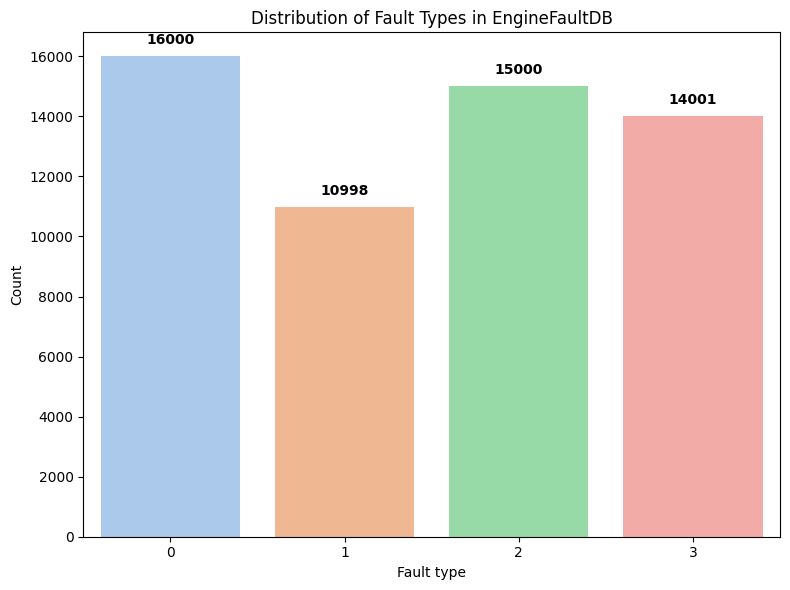

In [6]:
fault_counts = df['Fault'].value_counts().sort_index()

fault_df = pd.DataFrame({
    'Fault': fault_counts.index.astype(str),
    'Count': fault_counts.values
})

plt.figure(figsize=(8,6))

sns.barplot(
    data=fault_df,
    x='Fault',
    y='Count',
    hue='Fault',
    palette='pastel',
    dodge=False,
    legend=False
)

for i,count in enumerate(fault_df['Count']):
    plt.text(i, count + 300, str(count),
             ha='center',
             va='bottom',
             fontweight='bold')

plt.title('Distribution of Fault Types in EngineFaultDB')
plt.xlabel('Fault type')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Feature Correlation

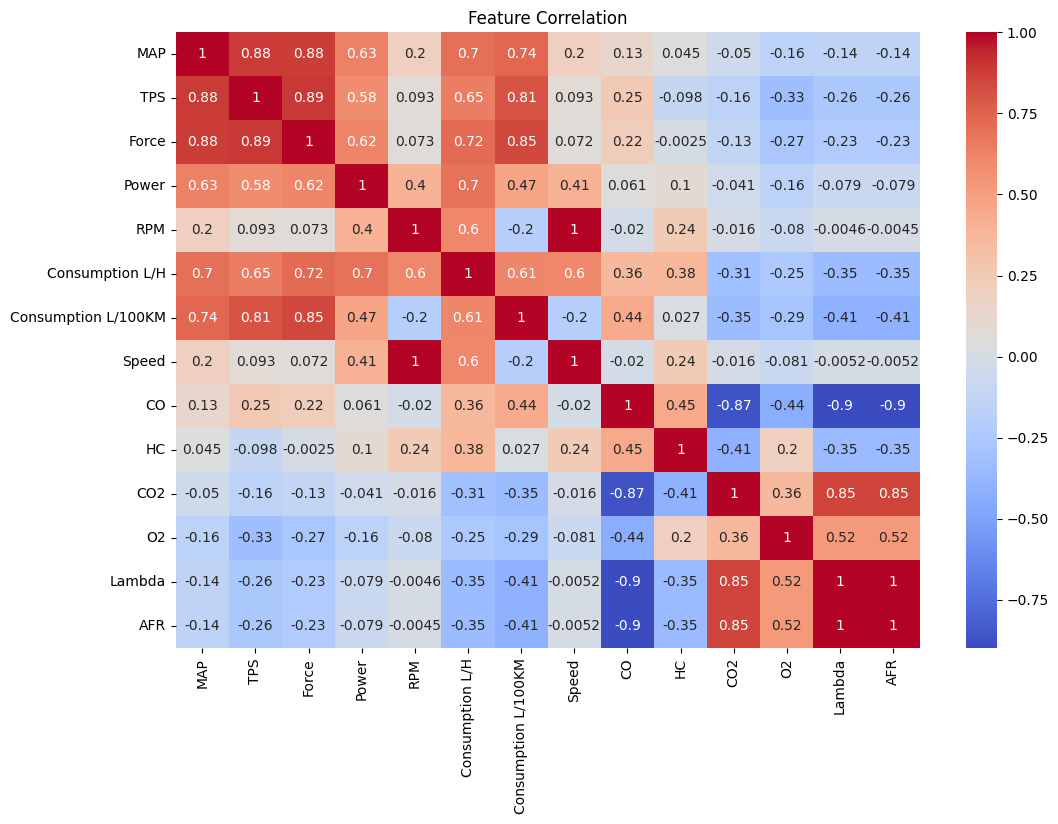

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("Fault", axis=1).corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation")

plt.show()

# Boxplots for Each Feature per Fault

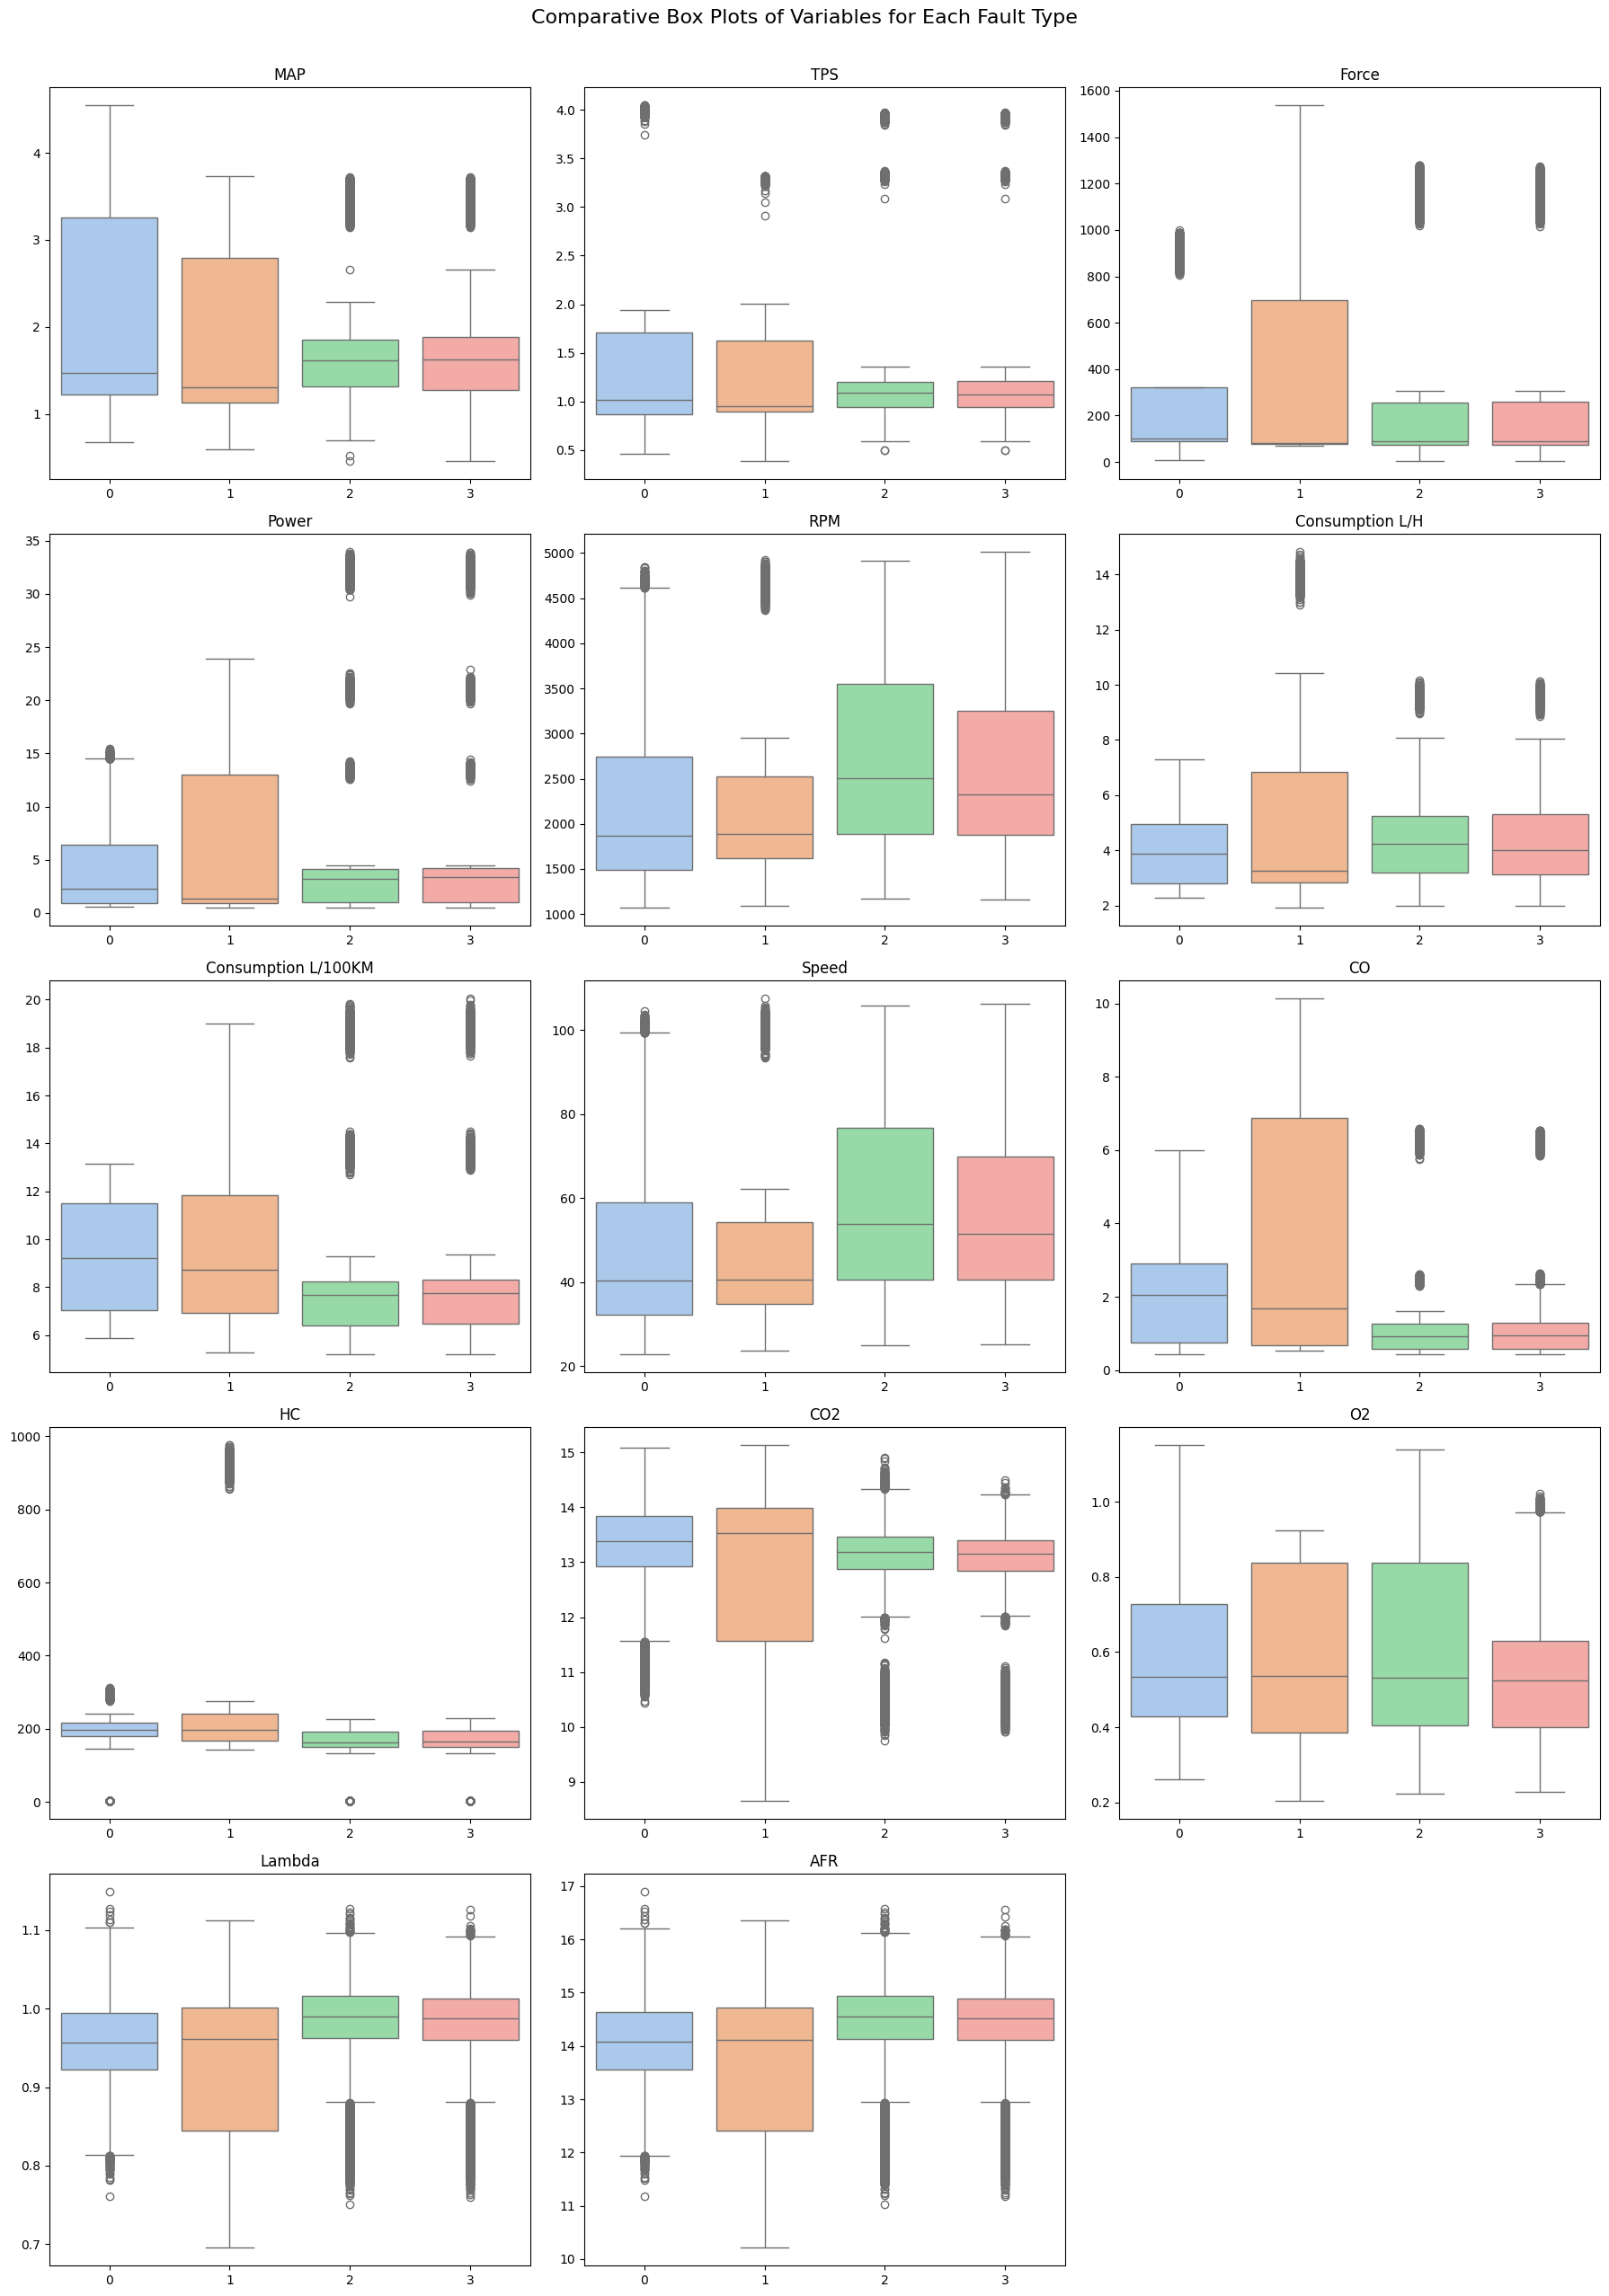

In [8]:
df['Fault'] = df['Fault'].astype(str)

features = df.columns.drop('Fault')

num_features = len(features)

rows = (num_features + 2) // 3

plt.figure(figsize=(18,5*rows))

for idx, feature in enumerate(features):

    plt.subplot(rows,3,idx+1)

    sns.boxplot(
        data=df,
        x='Fault',
        y=feature,
        hue='Fault',
        palette='pastel',
        dodge=False,
        legend=False
    )

    plt.title(feature)
    plt.xlabel("")
    plt.ylabel("")

plt.tight_layout()

plt.suptitle(
    'Comparative Box Plots of Variables for Each Fault Type',
    fontsize=16,
    y=1.02
)

plt.show()

# 4. Machine Learning Models

# 4.1 Logistic Regression

In [9]:
lr = LogisticRegression(max_iter=500)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")

print(classification_report(y_test, y_pred_lr))

print(confusion_matrix(y_test, y_pred_lr))

Logistic Regression
              precision    recall  f1-score   support

           0       0.71      0.75      0.73      3200
           1       0.66      0.62      0.64      2200
           2       0.46      0.45      0.45      3000
           3       0.50      0.50      0.50      2800

    accuracy                           0.58     11200
   macro avg       0.58      0.58      0.58     11200
weighted avg       0.58      0.58      0.58     11200

[[2400  665  131    4]
 [ 670 1361  163    6]
 [ 235   15 1348 1402]
 [  96   11 1285 1408]]


# 4.2 Decision Tree

In [10]:
dt = DecisionTreeClassifier(
    criterion='entropy',
    splitter='best',
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")

print(classification_report(y_test, y_pred_dt))

print(confusion_matrix(y_test, y_pred_dt))

Decision Tree
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.66      0.14      0.23      3000
           3       0.50      0.93      0.65      2800

    accuracy                           0.75     11200
   macro avg       0.79      0.77      0.72     11200
weighted avg       0.78      0.75      0.70     11200

[[3198    1    0    1]
 [   0 2198    2    0]
 [   0    2  411 2587]
 [   0    3  206 2591]]


# 4.3 Random Forest

In [11]:
rf = RandomForestClassifier(
    n_estimators=200,
    criterion='entropy',
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    bootstrap=True,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")

print(classification_report(y_test, y_pred_rf))

print(confusion_matrix(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.53      0.34      0.41      3000
           3       0.49      0.68      0.57      2800

    accuracy                           0.74     11200
   macro avg       0.76      0.75      0.75     11200
weighted avg       0.75      0.74      0.74     11200

[[3200    0    0    0]
 [   0 2200    0    0]
 [   0    0 1015 1985]
 [   0    0  896 1904]]


# 4.4 Support Vector Machine

In [12]:
svm = SVC()

svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Support Vector Machine")

print(classification_report(y_test, y_pred_svm))

print(confusion_matrix(y_test, y_pred_svm))

Support Vector Machine
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       0.99      1.00      0.99      2200
           2       0.51      0.35      0.41      3000
           3       0.48      0.64      0.55      2800

    accuracy                           0.73     11200
   macro avg       0.75      0.75      0.74     11200
weighted avg       0.74      0.73      0.73     11200

[[3200    0    0    0]
 [   1 2194    0    5]
 [   0    8 1042 1950]
 [   0   13  994 1793]]


# 4.5 K-Nearest Neighbors

In [13]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("K-Nearest Neighbors")

print(classification_report(y_test, y_pred_knn))

print(confusion_matrix(y_test, y_pred_knn))

K-Nearest Neighbors
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.53      0.54      0.53      3000
           3       0.50      0.50      0.50      2800

    accuracy                           0.75     11200
   macro avg       0.76      0.76      0.76     11200
weighted avg       0.75      0.75      0.75     11200

[[3200    0    0    0]
 [   0 2200    0    0]
 [   0    0 1608 1392]
 [   0    0 1408 1392]]


# 4.6 Naive Bayes

In [14]:
nb = GaussianNB()

nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes")

print(classification_report(y_test, y_pred_nb))

print(confusion_matrix(y_test, y_pred_nb))

Naive Bayes
              precision    recall  f1-score   support

           0       0.40      0.74      0.52      3200
           1       0.52      0.28      0.37      2200
           2       0.39      0.41      0.40      3000
           3       0.20      0.07      0.10      2800

    accuracy                           0.39     11200
   macro avg       0.38      0.38      0.35     11200
weighted avg       0.37      0.39      0.35     11200

[[2375  199  409  217]
 [ 808  624  420  348]
 [1380  202 1221  197]
 [1377  178 1055  190]]


# 4.7 Feedforward Neural Network

In [15]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(9, activation='relu'),
    Dense(6, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=32,
    validation_data=(X_test, y_test)
)

y_pred_nn = np.argmax(model.predict(X_test), axis=1)

print("Feedforward Neural Network")

print(classification_report(y_test, y_pred_nn))

print(confusion_matrix(y_test, y_pred_nn))

Epoch 1/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4666 - loss: 1.1610 - val_accuracy: 0.5912 - val_loss: 0.8966
Epoch 2/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6185 - loss: 0.7825 - val_accuracy: 0.6439 - val_loss: 0.7078
Epoch 3/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6533 - loss: 0.6662 - val_accuracy: 0.6567 - val_loss: 0.6389
Epoch 4/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6728 - loss: 0.6050 - val_accuracy: 0.6865 - val_loss: 0.5824
Epoch 5/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.6931 - loss: 0.5533 - val_accuracy: 0.7098 - val_loss: 0.5298
Epoch 6/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7033 - loss: 0.5029 - val_accuracy: 0.7023 - val_loss: 0.4824
Epoch 7/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7124 - loss: 0.4592 - val_accuracy: 0.7275 - val_loss: 0.4424
Epoch 8/30
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7313 - loss: 0.4273 - 

# 4.8 Confusion Matrices Comparison

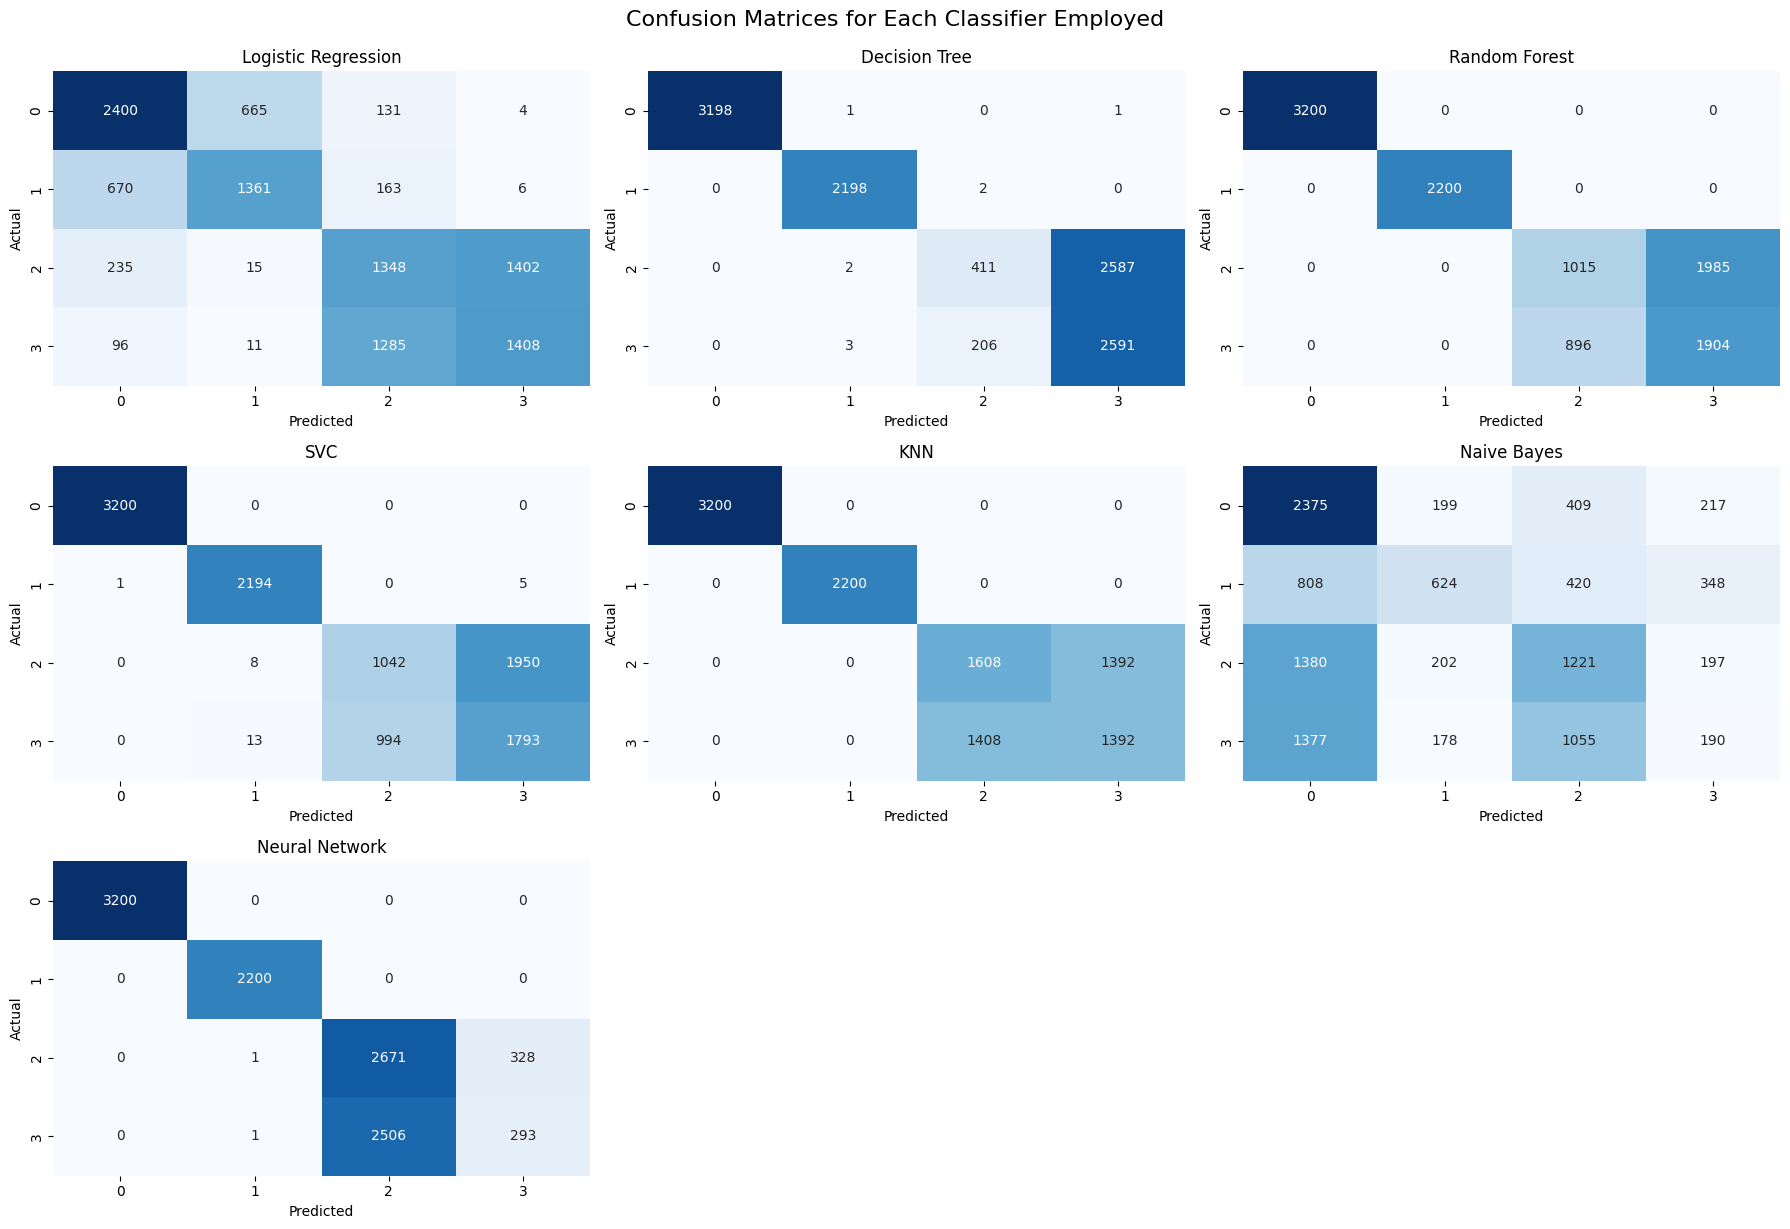

In [16]:
model_preds = {
    "Logistic Regression": y_pred_lr,
    "Decision Tree": y_pred_dt,
    "Random Forest": y_pred_rf,
    "SVC": y_pred_svm,
    "KNN": y_pred_knn,
    "Naive Bayes": y_pred_nb,
    "Neural Network": y_pred_nn
}

plt.figure(figsize=(18,12))

for i,(name,preds) in enumerate(model_preds.items()):

    plt.subplot(3,3,i+1)

    cm = confusion_matrix(y_test,preds)

    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',cbar=False)

    plt.title(name)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()

plt.suptitle(
    "Confusion Matrices for Each Classifier Employed",
    fontsize=16,
    y=1.02
)

plt.show()

# Final Performance Table

In [17]:
models = {
"LR": lr,
"DT": dt,
"RF": rf,
"SVC": svm,
"KNN": knn,
"NB": nb
}

nn_train_preds = np.argmax(model.predict(X_train), axis=1)

nn_test_preds = y_pred_nn

1400/1400 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


In [18]:
train_metrics = {}
test_metrics = {}

for name,model_obj in models.items():

    train_pred = model_obj.predict(X_train)

    test_pred = model_obj.predict(X_test)

    train_metrics[name] = [
        accuracy_score(y_train,train_pred),
        precision_score(y_train,train_pred,average='weighted'),
        recall_score(y_train,train_pred,average='weighted'),
        f1_score(y_train,train_pred,average='weighted')
    ]

    test_metrics[name] = [
        accuracy_score(y_test,test_pred),
        precision_score(y_test,test_pred,average='weighted'),
        recall_score(y_test,test_pred,average='weighted'),
        f1_score(y_test,test_pred,average='weighted')
    ]

In [19]:
train_metrics["Neural Net."] = [
    accuracy_score(y_train,nn_train_preds),
    precision_score(y_train,nn_train_preds,average='weighted'),
    recall_score(y_train,nn_train_preds,average='weighted'),
    f1_score(y_train,nn_train_preds,average='weighted')
]

test_metrics["Neural Net."] = [
    accuracy_score(y_test,y_pred_nn),
    precision_score(y_test,y_pred_nn,average='weighted'),
    recall_score(y_test,y_pred_nn,average='weighted'),
    f1_score(y_test,y_pred_nn,average='weighted')
]

In [20]:
columns = ["Accuracy","Precision","Recall","F1-score"]

train_df = pd.DataFrame(train_metrics,index=columns).T.round(3)

test_df = pd.DataFrame(test_metrics,index=columns).T.round(3)

print("Training Performance:")

display(train_df)

print("\nTesting Performance:")

display(test_df)

Training Performance:


,Accuracy,Precision,Recall,F1-score
LR,0.577,0.574,0.577,0.575
DT,0.760,0.812,0.760,0.717
RF,0.933,0.942,0.933,0.932
SVC,0.752,0.756,0.752,0.745
KNN,0.843,0.843,0.843,0.843
NB,0.393,0.372,0.393,0.352
Neural Net.,0.750,0.747,0.750,0.706



Testing Performance:


,Accuracy,Precision,Recall,F1-score
LR,0.582,0.580,0.582,0.581
DT,0.750,0.785,0.750,0.705
RF,0.743,0.747,0.743,0.735
SVC,0.735,0.737,0.735,0.729
KNN,0.750,0.750,0.750,0.750
NB,0.394,0.371,0.394,0.353
Neural Net.,0.747,0.738,0.747,0.700


# Deep Learning Experiments and Representation Analysis

In [21]:
from sklearn.decomposition import PCA
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.layers import (
    Conv1D,
    Flatten,
    Dropout,
    BatchNormalization,
    MaxPooling1D,
    LSTM
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.preprocessing import RobustScaler

from mpl_toolkits.mplot3d import Axes3D
import xgboost as xgb

In [22]:
X = df.drop('Fault', axis=1).values
y = df["Fault"].values

In [23]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

# PCA Visualization

# 2D PCA

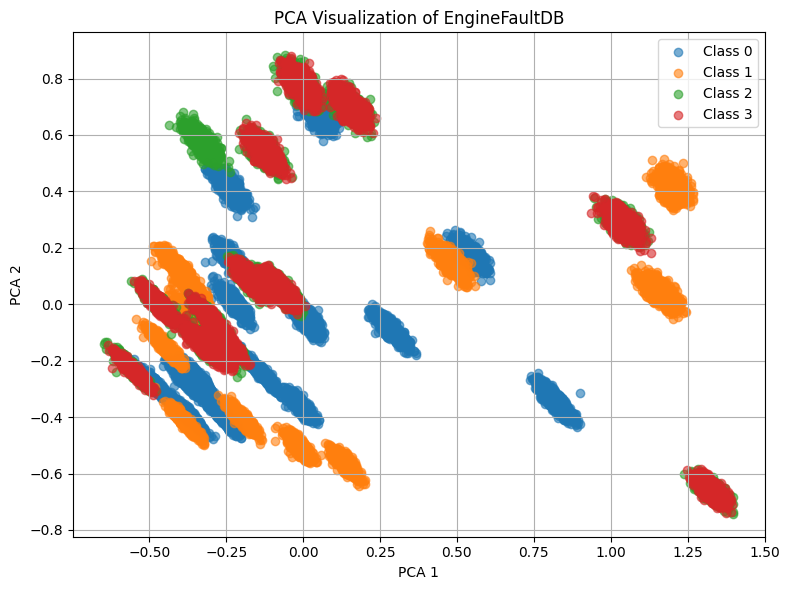

In [24]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

for label in np.unique(y):

    plt.scatter(
        X_pca[y==label,0],
        X_pca[y==label,1],
        label=f"Class {label}",
        alpha=0.6
    )

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()

plt.title("PCA Visualization of EngineFaultDB")

plt.grid(True)

plt.tight_layout()

plt.show()

# 3D PCA

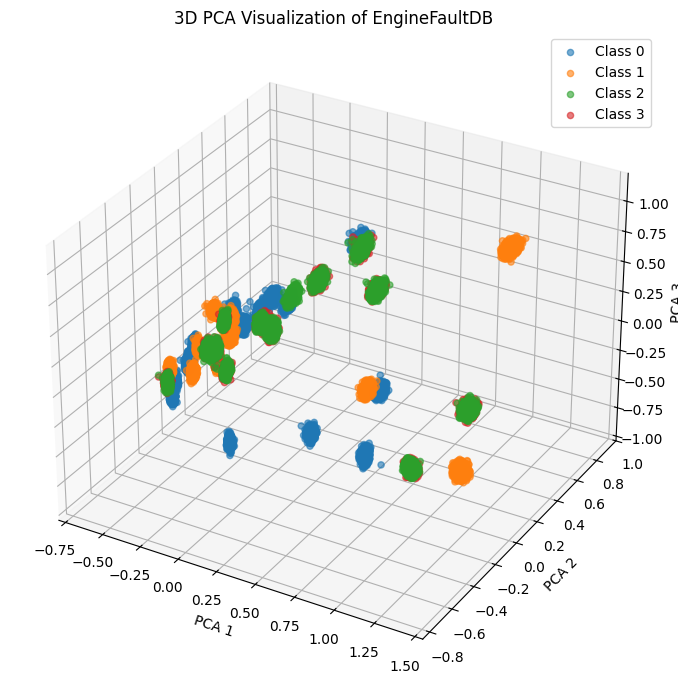

In [25]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

fig = plt.figure(figsize=(10,7))

ax = fig.add_subplot(111, projection='3d')

for label in np.unique(y):

    ax.scatter(
        X_pca[y==label,0],
        X_pca[y==label,1],
        X_pca[y==label,2],
        label=f"Class {label}",
        alpha=0.6
    )

ax.set_xlabel("PCA 1")
ax.set_ylabel("PCA 2")
ax.set_zlabel("PCA 3")

ax.set_title("3D PCA Visualization of EngineFaultDB")

ax.legend()

plt.tight_layout()

plt.show()

# This visualization helps show that Class 2 and 3 overlap, which becomes important later for hierarchical modeling.

# Deep Neural Network (DNN)

# One-hot labels

In [26]:
y_cat = to_categorical(y, num_classes=4)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_cat,
    test_size=0.2,
    random_state=42
)

# DNN Model

In [27]:
dnn_model = Sequential([

Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
Dropout(0.3),

Dense(64, activation='relu'),
Dropout(0.3),

Dense(32, activation='relu'),

Dense(4, activation='softmax')

])

dnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

dnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5952 - loss: 0.7833 - val_accuracy: 0.7458 - val_loss: 0.4276
Epoch 2/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7246 - loss: 0.4469 - val_accuracy: 0.7561 - val_loss: 0.3651
Epoch 3/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7375 - loss: 0.4022 - val_accuracy: 0.7613 - val_loss: 0.3529
Epoch 4/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7389 - loss: 0.3838 - val_accuracy: 0.7585 - val_loss: 0.3477
Epoch 5/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7387 - loss: 0.3760 - val_accuracy: 0.7537 - val_loss: 0.3440
Epoch 6/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7458 - loss: 0.3696 - val_accuracy: 0.7517 - val_loss: 0.3488
Epoch 7/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7404 - loss: 0.3666 - val_accuracy: 0.7535 - val_loss: 0.3447
Epoch 8/20
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7455 - loss: 0.3636 - val_accurac

# DNN Evaluation

350/350 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
DNN:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3229
           1       1.00      1.00      1.00      2194
           2       0.52      0.86      0.65      3020
           3       0.48      0.14      0.21      2757

    accuracy                           0.75     11200
   macro avg       0.75      0.75      0.72     11200
weighted avg       0.74      0.75      0.71     11200



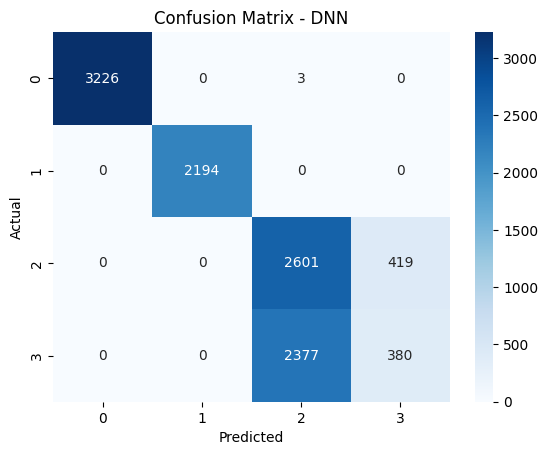

In [28]:
y_pred_probs = dnn_model.predict(X_test)

y_pred_dnn = np.argmax(y_pred_probs, axis=1)

y_true = np.argmax(y_test, axis=1)

print("DNN:")

print(classification_report(y_true, y_pred_dnn))

sns.heatmap(
    confusion_matrix(y_true, y_pred_dnn),
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix - DNN")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# 1D CNN Model

# Reshape Data

In [29]:
X_scaled = X_scaled.reshape(-1, X_scaled.shape[1], 1)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

# CNN Architecture

In [30]:
model = Sequential(name='EngineFault_CNN')

model.add(Input(shape=(X.shape[1],1)))

model.add(Conv1D(32,3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Conv1D(64,3,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.compile(
    optimizer=Adam(),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train CNN

In [31]:
history = model.fit(
    X_train,
    y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32
)

Epoch 1/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.5678 - loss: 0.9482 - val_accuracy: 0.7328 - val_loss: 0.4152
Epoch 2/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6959 - loss: 0.5355 - val_accuracy: 0.7462 - val_loss: 0.3740
Epoch 3/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7184 - loss: 0.4618 - val_accuracy: 0.7429 - val_loss: 0.3624
Epoch 4/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.7307 - loss: 0.4284 - val_accuracy: 0.7469 - val_loss: 0.3578
Epoch 5/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.7346 - loss: 0.4077 - val_accuracy: 0.7437 - val_loss: 0.3647
Epoch 6/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7364 - loss: 0.4033 - val_accuracy: 0.7473 - val_loss: 0.3601
Epoch 7/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7423 - loss: 0.3929 - val_accuracy: 0.7444 - val_loss: 0.3560
Epoch 8/20
1260/1260 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7392 - loss: 0.3889 

# CNN Evaluation

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7415 - loss: 0.3488
1D-CNN
Test Accuracy: 0.7415178418159485
350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.52      0.45      0.48      3000
           3       0.49      0.56      0.52      2800

    accuracy                           0.74     11200
   macro avg       0.75      0.75      0.75     11200
weighted avg       0.74      0.74      0.74     11200



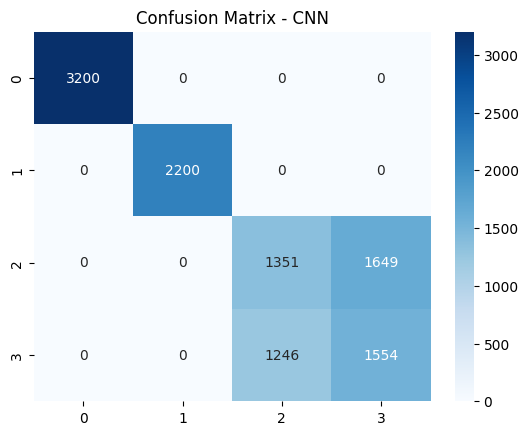

In [32]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print("1D-CNN")

print("Test Accuracy:", test_acc)

y_pred = np.argmax(model.predict(X_test), axis=1)

y_true = np.argmax(y_test_cat, axis=1)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - CNN")

plt.show()

# XGBoost Comparison

In [33]:
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [34]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)

model = xgb.XGBClassifier(

    objective='multi:softprob',
    num_class=4,
    eval_metric='mlogloss',

    learning_rate=0.1,
    max_depth=6,
    n_estimators=150,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

              precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000      3200
           1     1.0000    1.0000    1.0000      2200
           2     0.5161    0.5123    0.5142      3000
           3     0.4816    0.4854    0.4835      2800

    accuracy                         0.7407     11200
   macro avg     0.7494    0.7494    0.7494     11200
weighted avg     0.7408    0.7407    0.7407     11200



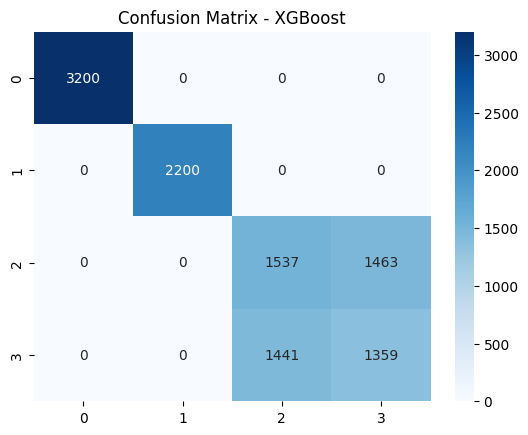

In [35]:
print(classification_report(y_test, y_pred, digits=4))

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - XGBoost")

plt.show()

# Selected Feature CNN

# Feature Selection

In [36]:
selected_features = [
'MAP',
'TPS',
'Force',
'Power',
'CO',
'HC',
'Consumption L/H',
'Consumption L/100KM'
]

X = df[selected_features]
y = df['Fault']

In [37]:
scaler = RobustScaler()

X_scaled = scaler.fit_transform(X)

In [38]:
X_scaled = X_scaled.reshape(-1, X_scaled.shape[1], 1)

y_cat = to_categorical(y, num_classes=4)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_cat,
    test_size=0.2,
    random_state=42
)

# CNN for Selected Features

In [39]:
model_cnn = Sequential([

Conv1D(32,3,activation='relu',input_shape=(X_scaled.shape[1],1)),
Dropout(0.2),

Conv1D(64,3,activation='relu'),
MaxPooling1D(2),

Flatten(),

Dense(64,activation='relu'),

Dense(4,activation='softmax')

])

model_cnn.compile(
optimizer=Adam(),
loss='categorical_crossentropy',
metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [40]:
model_cnn.fit(
X_train,
y_train,
epochs=15,
batch_size=32,
validation_split=0.2
)

Epoch 1/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6739 - loss: 0.6018 - val_accuracy: 0.7570 - val_loss: 0.3562
Epoch 2/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7425 - loss: 0.3752 - val_accuracy: 0.7523 - val_loss: 0.3457
Epoch 3/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7471 - loss: 0.3611 - val_accuracy: 0.7519 - val_loss: 0.3432
Epoch 4/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7443 - loss: 0.3565 - val_accuracy: 0.7528 - val_loss: 0.3467
Epoch 5/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7475 - loss: 0.3539 - val_accuracy: 0.7522 - val_loss: 0.3434
Epoch 6/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7485 - loss: 0.3522 - val_accuracy: 0.7519 - val_loss: 0.3455
Epoch 7/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7455 - loss: 0.3515 - val_accuracy: 0.7525 - val_loss: 0.3428
Epoch 8/15
1120/1120 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7521 - loss: 0.3521 -

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3229
           1       1.00      1.00      1.00      2194
           2       0.58      0.26      0.36      3020
           3       0.49      0.79      0.61      2757

    accuracy                           0.75     11200
   macro avg       0.77      0.76      0.74     11200
weighted avg       0.76      0.75      0.73     11200



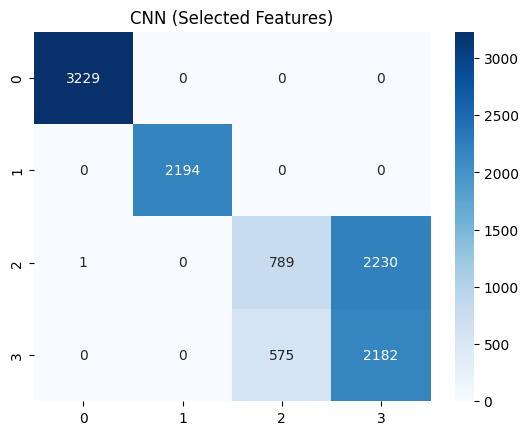

In [41]:
y_pred_cnn = np.argmax(model_cnn.predict(X_test),axis=1)

y_true = np.argmax(y_test,axis=1)

print(classification_report(y_true,y_pred_cnn))

sns.heatmap(confusion_matrix(y_true,y_pred_cnn),annot=True,fmt='d',cmap='Blues')

plt.title("CNN (Selected Features)")

plt.show()

# CNN + LSTM Hybrid Model

# Selected Features

In [42]:
selected_features = [
"CO",
"Force",
"Consumption L/100KM",
"Consumption L/H",
"RPM",
"O2",
"Power",
"HC",
"Speed"
]

X = df[selected_features].values
y = df["Fault"].values

In [43]:
scaler = MinMaxScaler()

X = scaler.fit_transform(X)

X = X.reshape(X.shape[0],X.shape[1],1)

In [44]:
X_train,X_test,y_train,y_test = train_test_split(
X,y,
stratify=y,
test_size=0.2,
random_state=42
)

In [45]:
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

# Class weights

In [46]:
weights = compute_class_weight(
class_weight='balanced',
classes=np.unique(y_train),
y=y_train
)

class_weights = {i:weights[i] for i in range(4)}

print(class_weights)

{0: np.float64(0.87498046875), 1: np.float64(1.2729881791316209), 2: np.float64(0.9333125), 3: np.float64(0.9998884028211766)}


# CNN + LSTM Model

In [47]:
model = Sequential(name="CNN_LSTM_EngineFault")

model.add(Input(shape=(X.shape[1],1)))

model.add(Conv1D(64,2,activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

model.add(LSTM(64, return_sequences=False))
model.add(Dropout(0.4))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4,activation='softmax'))

model.compile(
optimizer='adam',
loss='categorical_crossentropy',
metrics=['accuracy']
)

In [48]:
early_stop = EarlyStopping(
monitor='val_loss',
patience=10,
restore_best_weights=True
)

history = model.fit(
X_train,
y_train_cat,
validation_split=0.1,
epochs=60,
batch_size=64,
class_weight=class_weights,
callbacks=[early_stop]
)

Epoch 1/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.5723 - loss: 0.8244 - val_accuracy: 0.7129 - val_loss: 0.4546
Epoch 2/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7319 - loss: 0.4193 - val_accuracy: 0.7413 - val_loss: 0.3625
Epoch 3/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7473 - loss: 0.3653 - val_accuracy: 0.7435 - val_loss: 0.3554
Epoch 4/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7503 - loss: 0.3514 - val_accuracy: 0.7386 - val_loss: 0.3543
Epoch 5/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.7462 - loss: 0.3475 - val_accuracy: 0.7464 - val_loss: 0.3537
Epoch 6/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.7502 - loss: 0.3432 - val_accuracy: 0.7462 - val_loss: 0.3557
Epoch 7/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.7482 - loss: 0.3425 - val_accuracy: 0.7462 - val_loss: 0.3557
Epoch 8/60
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7497 - loss: 0.3409 - val_accuracy: 0.

350/350 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.52      0.36      0.42      3000
           3       0.49      0.65      0.56      2800

    accuracy                           0.74     11200
   macro avg       0.75      0.75      0.74     11200
weighted avg       0.74      0.74      0.73     11200



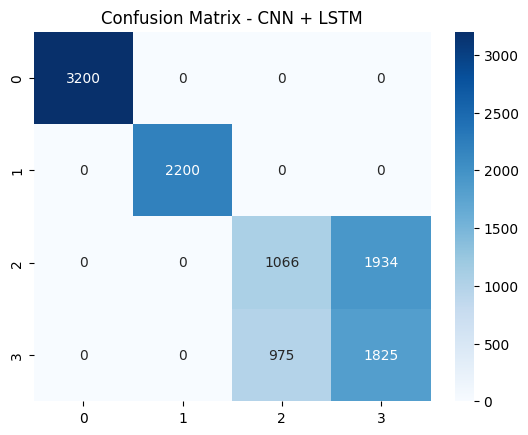

In [49]:
y_pred_probs = model.predict(X_test)

y_pred = np.argmax(y_pred_probs, axis=1)

y_true = y_test.astype(int)

print(classification_report(y_true, y_pred))

cm = confusion_matrix(y_true, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - CNN + LSTM")

plt.show()

# TabNet Model (Baseline Deep Tabular)

In [50]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, TensorDataset

from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.decomposition import PCA
import random

In [51]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

X_train = X_train.astype(np.float32)
X_test = X_test.astype(np.float32)
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [53]:
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1])
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1])

In [54]:
clf = TabNetClassifier(
    n_d=64,
    n_a=64,
    n_steps=5,
    gamma=1.5,
    lambda_sparse=1e-4,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10,"gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='sparsemax',
    verbose=10,
    seed=42
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


# Train TabNet

In [55]:
clf.fit(
    X_train=X_train,
    y_train=y_train,
    eval_set=[(X_test, y_test)],
    eval_name=["test"],
    eval_metric=["accuracy"],
    max_epochs=60,
    patience=15,
    batch_size=1024,
    virtual_batch_size=128
)

epoch 0  | loss: 1.08337 | test_accuracy: 0.53491 |  0:00:08s
epoch 10 | loss: 0.3666  | test_accuracy: 0.75045 |  0:01:37s
epoch 20 | loss: 0.35395 | test_accuracy: 0.74384 |  0:03:07s
epoch 30 | loss: 0.36074 | test_accuracy: 0.75098 |  0:04:38s

Early stopping occurred at epoch 39 with best_epoch = 24 and best_test_accuracy = 0.75205


/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


# Evaluate TabNet

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.70      0.13      0.22      3000
           3       0.50      0.94      0.65      2800

    accuracy                           0.75     11200
   macro avg       0.80      0.77      0.72     11200
weighted avg       0.80      0.75      0.70     11200



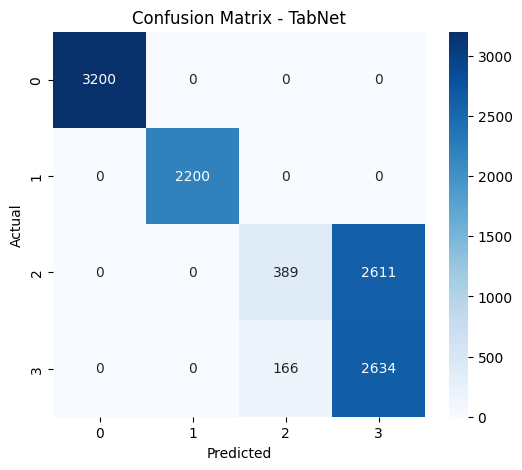

In [56]:
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix - TabNet")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Siamese Network (Class 2 vs 3)

# Filter dataset

In [57]:
df = pd.read_csv(url)
df_bin = df[df["Fault"].isin([2, 3])].reset_index(drop=True)

X = df_bin.drop(columns=["Fault"]).values
y = df_bin["Fault"].values
y = np.where(y == 2, 0, 1)  # Convert: 2→0, 3→1 for binary siamese

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

if len(X_scaled.shape) == 3:
    X_scaled = X_scaled.reshape(X_scaled.shape[0], X_scaled.shape[1])

# Siamese Dataset

In [58]:
class SiameseDataset(Dataset):

    def __init__(self,X,y,pairs=8000):

        self.X = X
        self.y = y
        self.pairs = pairs
        self.data = self.create_pairs()

    def create_pairs(self):

        pairs=[]

        for _ in range(self.pairs):

            if random.random()<0.5:

                cls=random.choice([0,1])
                idx1,idx2=np.random.choice(np.where(self.y==cls)[0],2,replace=False)
                label=1

            else:

                idx1=random.choice(np.where(self.y==0)[0])
                idx2=random.choice(np.where(self.y==1)[0])
                label=0

            pairs.append((self.X[idx1],self.X[idx2],label))

        return pairs

    def __len__(self):
        return len(self.data)

    def __getitem__(self,idx):

        x1,x2,label=self.data[idx]

        return (
            torch.tensor(x1,dtype=torch.float32),
            torch.tensor(x2,dtype=torch.float32),
            torch.tensor(label,dtype=torch.float32)
        )

# Siamese Network

In [59]:
class EmbeddingNetwork(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim,64),
            nn.ReLU(),
            nn.Linear(64,32),
            nn.ReLU()
        )

    def forward(self,x):

        return self.fc(x)


class SiameseNetwork(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.embedding = EmbeddingNetwork(input_dim)

    def forward(self,x1,x2):

        out1 = self.embedding(x1)
        out2 = self.embedding(x2)

        return out1,out2

# Contrastive Loss

In [60]:
class ContrastiveLoss(nn.Module):

    def __init__(self,margin=1.0):

        super().__init__()
        self.margin = margin

    def forward(self,out1,out2,label):

        dist = torch.nn.functional.pairwise_distance(out1,out2)

        loss = label*dist.pow(2) + (1-label)*torch.clamp(self.margin-dist,min=0).pow(2)

        return loss.mean()

# Train Siamese Network

In [61]:
dataset = SiameseDataset(X_scaled,y)

loader = DataLoader(dataset,batch_size=128,shuffle=True)

model = SiameseNetwork(X.shape[1])

criterion = ContrastiveLoss()

optimizer = torch.optim.Adam(model.parameters(),lr=1e-3)

print("Training Siamese Network")

for epoch in range(15):

    model.train()

    running_loss = 0

    for x1,x2,label in loader:

        out1,out2 = model(x1,x2)

        loss = criterion(out1,out2,label)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1} | Loss {running_loss/len(loader):.4f}")

Training Siamese Network
Epoch 1 | Loss 0.2874
Epoch 2 | Loss 0.2726
Epoch 3 | Loss 0.2719
Epoch 4 | Loss 0.2698
Epoch 5 | Loss 0.2688
Epoch 6 | Loss 0.2676
Epoch 7 | Loss 0.2669
Epoch 8 | Loss 0.2658
Epoch 9 | Loss 0.2660
Epoch 10 | Loss 0.2657
Epoch 11 | Loss 0.2648
Epoch 12 | Loss 0.2639
Epoch 13 | Loss 0.2639
Epoch 14 | Loss 0.2633
Epoch 15 | Loss 0.2634


# Generate Embeddings

In [62]:
model.eval()

with torch.no_grad():

    embeddings = model.embedding(
        torch.tensor(X_scaled,dtype=torch.float32)
    ).numpy()

# Visualize Embeddings

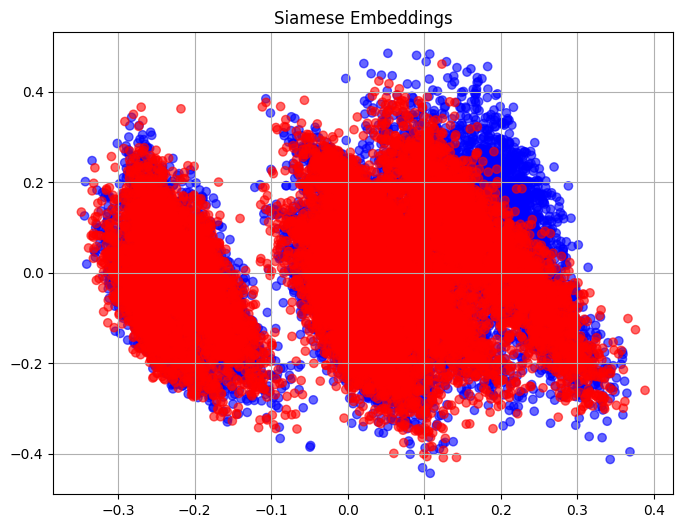

In [63]:
pca = PCA(n_components=2)

emb_2d = pca.fit_transform(embeddings)

colors = ['blue' if i==0 else 'red' for i in y]

plt.figure(figsize=(8,6))

plt.scatter(emb_2d[:,0],emb_2d[:,1],c=colors,alpha=0.6)

plt.title("Siamese Embeddings")

plt.grid(True)

plt.show()

# Train Classifier on Embeddings

In [64]:
X_train_emb,X_test_emb,y_train_bin,y_test_bin = train_test_split(
    embeddings,y,test_size=0.2,stratify=y,random_state=42
)

train_dataset = TensorDataset(
    torch.tensor(X_train_emb,dtype=torch.float32),
    torch.tensor(y_train_bin,dtype=torch.long)
)

test_dataset = TensorDataset(
    torch.tensor(X_test_emb,dtype=torch.float32),
    torch.tensor(y_test_bin,dtype=torch.long)
)

train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64)

# MLP Classifier

In [65]:
class MLPClassifier(nn.Module):

    def __init__(self,input_dim):

        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim,32),
            nn.ReLU(),

            nn.Linear(32,16),
            nn.ReLU(),

            nn.Linear(16,2)
        )

    def forward(self,x):

        return self.model(x)

# Train MLP

In [66]:
mlp_model = MLPClassifier(embeddings.shape[1])

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(mlp_model.parameters(),lr=0.001)

for epoch in range(15):

    mlp_model.train()

    loss_sum=0

    for xb,yb in train_loader:

        logits = mlp_model(xb)

        loss = criterion(logits,yb)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        loss_sum+=loss.item()

    print(epoch+1,loss_sum/len(train_loader))

1 0.6909464955658295
2 0.683979248704989
3 0.6781503620554922
4 0.6741466786578996
5 0.6715438577754438
6 0.6708004908128218
7 0.6702764111445298
8 0.6698230053439285
9 0.6697515239400312
10 0.6697276214922755
11 0.6695525575603664
12 0.669467407317201
13 0.6695684549237085
14 0.6694746293312261
15 0.6694678774221541


# Evaluate Embedding Classifier

              precision    recall  f1-score   support

           0       0.65      0.11      0.19      3000
           1       0.50      0.94      0.65      2801

    accuracy                           0.51      5801
   macro avg       0.57      0.52      0.42      5801
weighted avg       0.58      0.51      0.41      5801



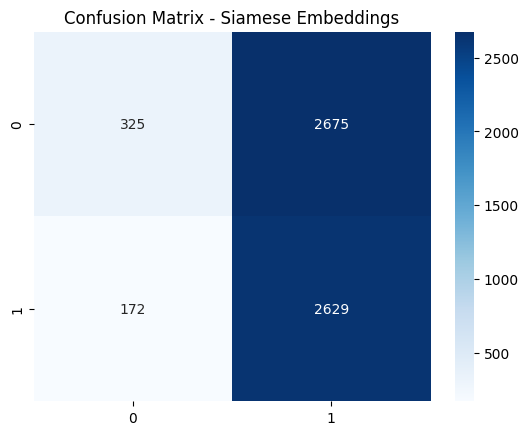

In [67]:
mlp_model.eval()

y_preds=[]
y_true=[]

with torch.no_grad():

    for xb,yb in test_loader:

        logits = mlp_model(xb)

        preds = torch.argmax(logits,dim=1)

        y_preds.extend(preds.tolist())

        y_true.extend(yb.tolist())


print(classification_report(y_true,y_preds))

cm = confusion_matrix(y_true,y_preds)

sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')

plt.title("Confusion Matrix - Siamese Embeddings")

plt.show()

# Triplet Network

In [68]:
class TripletDataset(Dataset):
    def __init__(self, X, y, n_triplets=8000):
        self.X = X
        self.y = y
        self.n_triplets = n_triplets
        self.triplets = self._create_triplets()

    def _create_triplets(self):
        triplets = []
        for _ in range(self.n_triplets):
            anchor_class = random.choice([0, 1])
            negative_class = 1 - anchor_class

            anchor_idx, pos_idx = np.random.choice(np.where(self.y == anchor_class)[0], 2, replace=False)
            neg_idx = np.random.choice(np.where(self.y == negative_class)[0], 1)[0]

            triplets.append((self.X[anchor_idx], self.X[pos_idx], self.X[neg_idx]))
        return triplets

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        a, p, n = self.triplets[idx]
        return (torch.tensor(a, dtype=torch.float32),
                torch.tensor(p, dtype=torch.float32),
                torch.tensor(n, dtype=torch.float32))

In [69]:
class TripletEmbeddingNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

    def forward(self, x):
        return self.fc(x)

In [70]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        dist_pos = torch.nn.functional.pairwise_distance(anchor, positive)
        dist_neg = torch.nn.functional.pairwise_distance(anchor, negative)
        losses = torch.relu(dist_pos - dist_neg + self.margin)
        return losses.mean()

In [71]:
input_dim = X.shape[1]
dataset = TripletDataset(X_scaled, y)
loader = DataLoader(dataset, batch_size=128, shuffle=True)

In [72]:
model = TripletEmbeddingNet(input_dim)
criterion = TripletLoss(margin=1.0)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [73]:
print("Training Triplet Network:")
for epoch in range(15):
    model.train()
    total_loss = 0
    for anchor, pos, neg in loader:
        anchor_out = model(anchor)
        pos_out = model(pos)
        neg_out = model(neg)

        loss = criterion(anchor_out, pos_out, neg_out)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {total_loss / len(loader):.4f}")

model.eval()
with torch.no_grad():
    embeddings = model(torch.tensor(X_scaled, dtype=torch.float32)).numpy()

Training Triplet Network:
Epoch 1 | Loss: 1.0040
Epoch 2 | Loss: 0.9999
Epoch 3 | Loss: 0.9977
Epoch 4 | Loss: 0.9958
Epoch 5 | Loss: 0.9949
Epoch 6 | Loss: 0.9931
Epoch 7 | Loss: 0.9927
Epoch 8 | Loss: 0.9923
Epoch 9 | Loss: 0.9913
Epoch 10 | Loss: 0.9905
Epoch 11 | Loss: 0.9903
Epoch 12 | Loss: 0.9905
Epoch 13 | Loss: 0.9887
Epoch 14 | Loss: 0.9896
Epoch 15 | Loss: 0.9879


In [74]:
X_train_emb, X_test_emb, y_train_bin, y_test_bin = train_test_split(
    embeddings, y, test_size=0.2, stratify=y, random_state=42
)

In [75]:
train_dataset = TensorDataset(
    torch.tensor(X_train_emb, dtype=torch.float32),
    torch.tensor(y_train_bin, dtype=torch.long)
)
test_dataset = TensorDataset(
    torch.tensor(X_test_emb, dtype=torch.float32),
    torch.tensor(y_test_bin, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [76]:
class MLPClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        return self.model(x)

In [77]:
mlp_model = MLPClassifier(input_dim=embeddings.shape[1])
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=0.001)

In [78]:
print("Training MLP on Triplet Embeddings:")
for epoch in range(15):
    mlp_model.train()
    running_loss = 0
    for xb, yb in train_loader:
        out = mlp_model(xb)
        loss = criterion(out, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1} | Loss: {running_loss / len(train_loader):.4f}")

Training MLP on Triplet Embeddings:
Epoch 1 | Loss: 0.6914
Epoch 2 | Loss: 0.6896
Epoch 3 | Loss: 0.6885
Epoch 4 | Loss: 0.6857
Epoch 5 | Loss: 0.6798
Epoch 6 | Loss: 0.6751
Epoch 7 | Loss: 0.6725
Epoch 8 | Loss: 0.6711
Epoch 9 | Loss: 0.6703
Epoch 10 | Loss: 0.6702
Epoch 11 | Loss: 0.6700
Epoch 12 | Loss: 0.6697
Epoch 13 | Loss: 0.6697
Epoch 14 | Loss: 0.6696
Epoch 15 | Loss: 0.6694


In [79]:
mlp_model.eval()
y_preds = []
y_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        preds = mlp_model(xb)
        preds = torch.argmax(preds, dim=1)
        y_preds.extend(preds.tolist())
        y_true.extend(yb.tolist())


MLP Classifier Report - Triplet Embeddings:
              precision    recall  f1-score   support

     Class 2       0.52      1.00      0.68      3000
     Class 3       0.00      0.00      0.00      2801

    accuracy                           0.52      5801
   macro avg       0.26      0.50      0.34      5801
weighted avg       0.27      0.52      0.35      5801



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


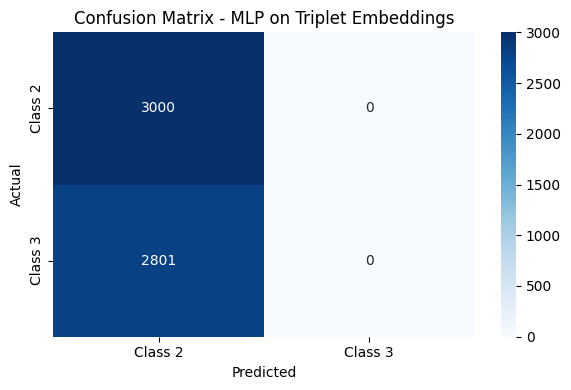

In [80]:
print("\nMLP Classifier Report - Triplet Embeddings:")
print(classification_report(y_true, y_preds, target_names=["Class 2", "Class 3"]))

cm = confusion_matrix(y_true, y_preds)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Class 2", "Class 3"], yticklabels=["Class 2", "Class 3"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - MLP on Triplet Embeddings")
plt.tight_layout()
plt.show()

# Class 2 vs 3 Misclassification Analysis

In [81]:
X = df.drop("Fault", axis=1).values
y = df["Fault"].values

In [82]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Train and Evaluate XGBoost Classifier

In [83]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

In [84]:
xgb_model = XGBClassifier(
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [85]:
y_pred = xgb_model.predict(X_test)

print("XGBoost Report:")
print(classification_report(y_test, y_pred))

XGBoost Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.53      0.51      0.52      3000
           3       0.50      0.52      0.51      2800

    accuracy                           0.75     11200
   macro avg       0.76      0.76      0.76     11200
weighted avg       0.75      0.75      0.75     11200



# Test Confusion Matrix

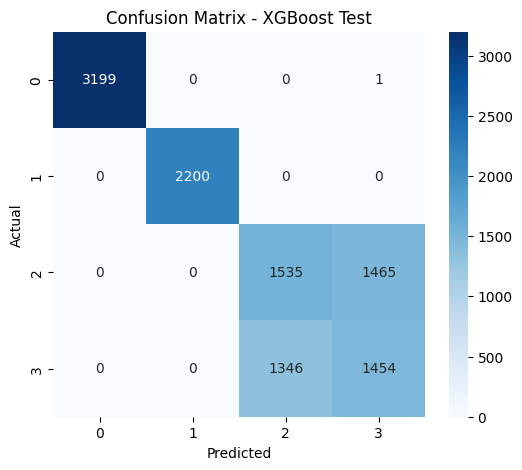

In [86]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - XGBoost Test")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Training Confusion Matrix

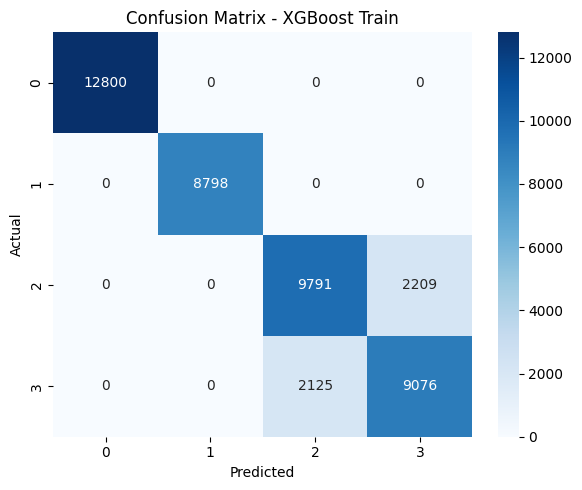

In [87]:
y_pred_train = xgb_model.predict(X_train)

cm = confusion_matrix(y_train, y_pred_train)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Confusion Matrix - XGBoost Train")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.tight_layout()

plt.show()

# Extract Misclassified Samples (2 ↔ 3)

In [88]:
y_test_labels = label_encoder.inverse_transform(y_test)

y_pred_labels = label_encoder.inverse_transform(y_pred.flatten())

X_test_df = pd.DataFrame(
    X_test,
    columns=df.drop("Fault", axis=1).columns
)

X_test_df["Fault"] = y_test_labels

# Find 2 → 3 mistakes

In [89]:
misclassified_2_to_3_idx = np.where(
    (y_test_labels == 2) &
    (y_pred_labels == 3)
)[0]

# Find 2 → 3 mistakes

In [90]:
misclassified_3_to_2_idx = np.where(
    (y_test_labels == 3) &
    (y_pred_labels == 2)
)[0]

In [91]:
# Combine both

misclassified_idx = np.concatenate([
    misclassified_2_to_3_idx,
    misclassified_3_to_2_idx
])

# Save Misclassified Samples

In [92]:
misclassified_samples = X_test_df.iloc[misclassified_idx].copy()

misclassified_samples["True_Label"] = y_test_labels[misclassified_idx]

misclassified_samples["Predicted_Label"] = y_pred_labels[misclassified_idx]

# misclassified_samples.to_csv(
#     "xgb_test_misclassified_2_vs_3.csv",
#     index=False
# )

misclassified_samples.head()

,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR,Fault,True_Label,Predicted_Label
5,0.303615,0.233224,0.060191,0.057495,0.710398,0.274568,0.093632,0.703888,0.019051,0.164326,0.797068,0.456751,0.790749,0.790813,2,2,3
17,0.251343,0.216585,0.055400,0.924584,0.698625,0.244396,0.073573,0.702449,0.022552,0.148875,0.754167,0.410338,0.742291,0.743229,2,2,3
21,0.278701,0.199945,0.154745,0.095039,0.396640,0.190569,0.206045,0.379467,0.094017,0.165414,0.737037,0.194093,0.616740,0.617088,2,2,3
39,0.716414,0.966721,0.799907,0.390789,0.194266,0.454898,0.906906,0.192954,0.595304,0.000606,0.264969,0.043249,0.299559,0.300314,2,2,3
43,0.271128,0.216585,0.056803,0.973985,0.673020,0.241992,0.080708,0.696858,0.022037,0.149165,0.711111,0.401899,0.665198,0.665869,2,2,3


# Feature Overlap Analysis (2 vs 3)

In [93]:
df_23 = X_test_df[X_test_df["Fault"].isin([2,3])]

features = df.drop("Fault", axis=1).columns

summary = []

# Compute overlap ratio

In [94]:
for feature in features:

    c2 = df_23[df_23["Fault"] == 2][feature]
    c3 = df_23[df_23["Fault"] == 3][feature]

    min2, max2 = c2.min(), c2.max()
    min3, max3 = c3.min(), c3.max()

    overlap_start = max(min2, min3)
    overlap_end = min(max2, max3)

    overlap_width = max(0, overlap_end - overlap_start)

    full_range = max(max2, max3) - min(min2, min3)

    overlap_ratio = overlap_width / full_range if full_range else 0

    summary.append({
        "Feature": feature,
        "Overlap Ratio (%)": round(overlap_ratio*100,1)
    })

# Overlap Table

In [95]:
df_overlap = pd.DataFrame(summary)

df_overlap_sorted = df_overlap.sort_values(
    "Overlap Ratio (%)",
    ascending=False
)

print(df_overlap_sorted)

                Feature  Overlap Ratio (%)
2                 Force               99.8
8                    CO               99.4
3                 Power               99.3
1                   TPS               99.1
5       Consumption L/H               98.9
6   Consumption L/100KM               98.3
7                 Speed               98.3
9                    HC               98.1
4                   RPM               96.9
10                  CO2               88.9
11                   O2               86.1
12               Lambda               85.9
13                  AFR               85.8
0                   MAP               83.5


# Overlap Visualization

/tmp/ipykernel_13769/1452651908.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


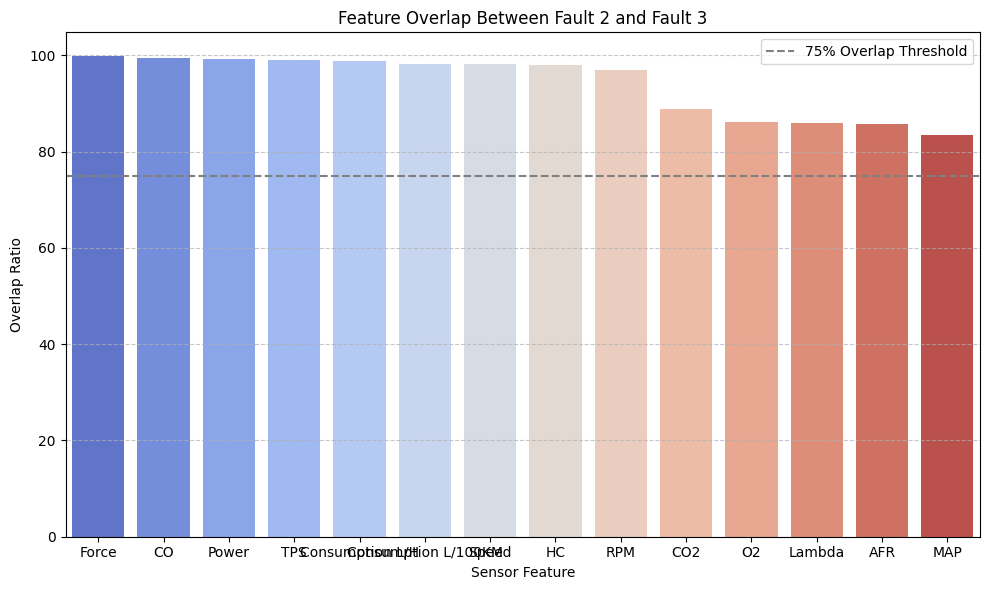

In [96]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Feature",
    y="Overlap Ratio (%)",
    data=df_overlap_sorted,
    palette="coolwarm"
)

plt.axhline(
    75,
    color="gray",
    linestyle="--",
    label="75% Overlap Threshold"
)

plt.title("Feature Overlap Between Fault 2 and Fault 3")

plt.ylabel("Overlap Ratio")

plt.xlabel("Sensor Feature")

plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.show()

# This plot shows extreme overlap for most sensors, explaining the confusion.

                Feature  Class 0 Min  Class 0 Max  Class 1 Min  Class 1 Max  \
4                   RPM        0.000        0.957        0.011        0.973   
7                 Speed        0.010        0.952        0.013        0.975   
0                   MAP        0.117        0.776        0.119        0.801   
1                   TPS        0.056        0.997        0.005        0.800   
13                  AFR        0.194        1.000        0.023        0.895   
12               Lambda        0.194        1.000        0.022        0.896   
11                   O2        0.066        0.985        0.004        0.758   
10                  CO2        0.308        0.978        0.025        0.978   
3                 Power        0.003        0.441        0.000        0.677   
2                 Force        0.003        0.641        0.044        0.997   
8                    CO        0.001        0.569        0.012        1.000   
6   Consumption L/100KM        0.054        0.534   

/tmp/ipykernel_13769/3898192732.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Feature', y='Overlap Ratio (%)', data=df_overlap_sorted, palette='coolwarm')


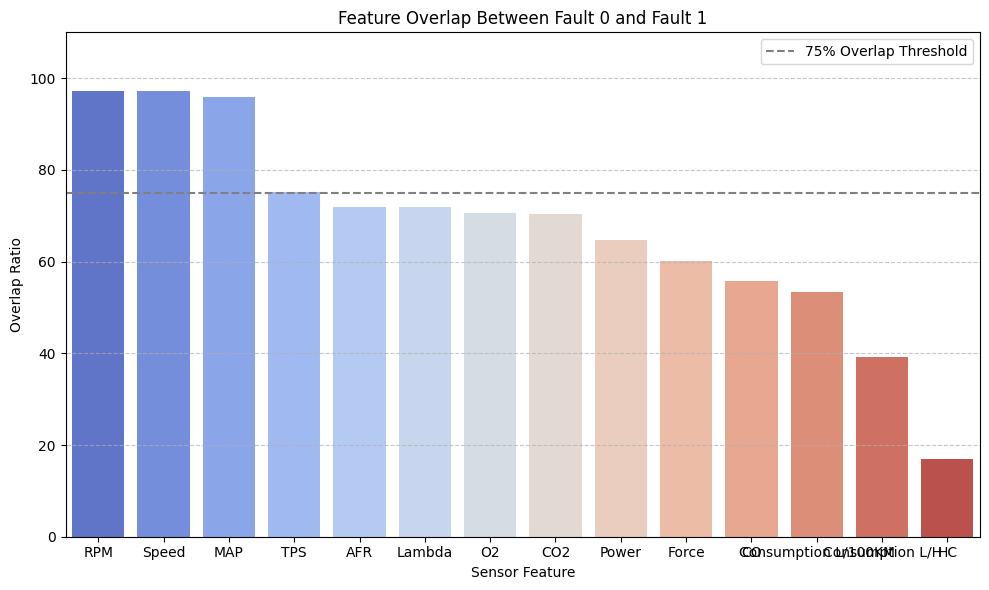

In [97]:
df_01 = X_test_df[X_test_df['Fault'].isin([0, 1])]

features = ['MAP', 'TPS', 'Force', 'Power', 'RPM', 'Consumption L/H', 'Consumption L/100KM', 'Speed', 'CO', 'HC', 'CO2', 'O2', 'Lambda', 'AFR']

summary = []
for feature in features:
    c0 = df_01[df_01['Fault'] == 0][feature]
    c1 = df_01[df_01['Fault'] == 1][feature]

    min0, max0 = c0.min(), c0.max()
    min1, max1 = c1.min(), c1.max()

    overlap_start = max(min0, min1)
    overlap_end = min(max0, max1)
    overlap_width = max(0, overlap_end - overlap_start)
    full_range = max(max0, max1) - min(min0, min1)
    overlap_ratio = overlap_width / full_range if full_range else 0

    summary.append({
        'Feature': feature,
        'Class 0 Min': round(min0, 3),
        'Class 0 Max': round(max0, 3),
        'Class 1 Min': round(min1, 3),
        'Class 1 Max': round(max1, 3),
        'Overlap Start': round(overlap_start, 3),
        'Overlap End': round(overlap_end, 3),
        'Overlap Width': round(overlap_width, 3),
        'Full Range': round(full_range, 3),
        'Overlap Ratio (%)': round(overlap_ratio * 100, 1)
    })

df_overlap = pd.DataFrame(summary)
df_overlap_sorted = df_overlap.sort_values('Overlap Ratio (%)', ascending=False)
print(df_overlap_sorted)

plt.figure(figsize=(10, 6))
sns.barplot(x='Feature', y='Overlap Ratio (%)', data=df_overlap_sorted, palette='coolwarm')

plt.axhline(75, color='gray', linestyle='--', label='75% Overlap Threshold')

plt.title('Feature Overlap Between Fault 0 and Fault 1')
plt.ylabel('Overlap Ratio')
plt.xlabel('Sensor Feature')
plt.ylim(0, 110)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# t-SNE Visualization

In [98]:
from sklearn.manifold import TSNE

df_23 = df[df["Fault"].isin([2,3])]

X = df_23.drop(columns=["Fault"])
y = df_23["Fault"]

In [99]:
scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30,
    max_iter=1000
)

X_tsne = tsne.fit_transform(X_scaled)

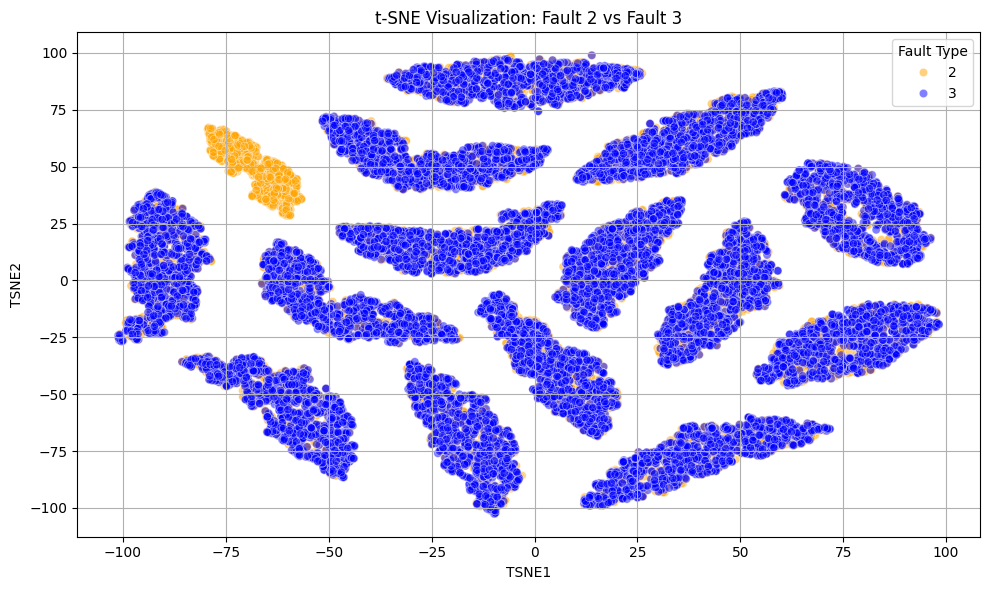

In [100]:
tsne_df = pd.DataFrame(X_tsne, columns=["TSNE1","TSNE2"])

tsne_df["Fault"] = y.values

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=tsne_df,
    x="TSNE1",
    y="TSNE2",
    hue="Fault",
    palette={2:"orange",3:"blue"},
    alpha=0.5
)

plt.title("t-SNE Visualization: Fault 2 vs Fault 3")

plt.legend(title="Fault Type")

plt.grid(True)

plt.tight_layout()

plt.show()

# The plot shows heavy cluster overlap between the two faults, confirming why ML models struggle to separate them.

# Misclassified Distribution of Class 2 vs 3

In [101]:
X = df.drop("Fault", axis=1)
y = df["Fault"]

X_original = X.copy()

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_scaled, X_test_scaled, y_train, y_test, X_train_orig, X_test_orig = train_test_split(
    X_scaled, y_encoded, X_original, test_size=0.2, stratify=y_encoded, random_state=42
)

In [102]:
xgb_model = XGBClassifier(eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [103]:
y_proba = xgb_model.predict_proba(X_test_scaled)
y_pred = np.argmax(y_proba, axis=1)

In [104]:
X_test_df = pd.DataFrame(X_test_orig, columns=df.drop("Fault", axis=1).columns)
X_test_df["true"] = y_test
X_test_df["pred"] = y_pred

In [105]:
misclassified_mask = y_pred != y_test

df_conf_all = X_test_df[misclassified_mask].copy()
df_conf_all["conf_pred"] = y_proba[misclassified_mask, y_pred[misclassified_mask]]
df_conf_all["conf_true"] = y_proba[misclassified_mask, y_test[misclassified_mask]]

In [106]:
df_conf_23 = df_conf_all[
    ((df_conf_all["true"] == 2) & (df_conf_all["pred"] == 3)) |
    ((df_conf_all["true"] == 3) & (df_conf_all["pred"] == 2))
].copy()

print(f"🎯 Misclassified between 2 and 3: {len(df_conf_23)}")
# df_conf_23.to_csv("xgb_test_misclassified_2_vs_3_conf.csv", index=False)
df_conf_23

🎯 Misclassified between 2 and 3: 2811


,MAP,TPS,Force,Power,RPM,Consumption L/H,Consumption L/100KM,Speed,CO,HC,CO2,O2,Lambda,AFR,true,pred,conf_pred,conf_true
38799,1.696,1.237,94.945,2.390,3870.358,5.457,6.578,82.434,0.606,161.819,13.814,0.636,1.054,15.495,2,3,0.637765,0.362082
51510,1.400,0.891,71.988,1.009,2150.142,2.881,6.596,44.449,2.541,194.386,12.458,0.410,0.957,14.070,3,2,0.515740,0.484140
39436,1.482,1.176,87.593,31.421,3823.891,5.068,6.280,82.312,0.640,146.772,13.536,0.592,1.032,15.177,2,3,0.543145,0.456822
31014,1.594,1.115,240.042,3.647,2631.970,4.374,8.248,54.929,1.334,162.879,13.425,0.387,0.975,14.334,2,3,0.518498,0.481462
44495,3.447,3.926,1213.810,13.671,1807.236,7.800,18.580,39.617,6.482,2.264,10.520,0.237,0.819,12.037,3,2,0.662637,0.337167
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54163,1.166,0.993,75.670,0.991,1858.431,3.528,9.063,39.931,1.147,160.736,13.251,0.520,1.017,14.957,3,2,0.605884,0.394061
31424,1.685,1.136,235.039,3.655,2602.172,4.427,7.931,55.053,1.280,163.479,13.588,0.395,1.007,14.806,2,3,0.669945,0.329977
40317,1.084,0.952,77.165,0.975,1945.254,3.377,8.434,43.213,1.128,154.844,12.901,0.511,0.974,14.311,2,3,0.548707,0.451107
42465,1.746,0.952,286.605,3.123,1905.488,3.182,7.557,40.390,0.448,218.870,13.027,0.850,1.020,14.998,3,2,0.584465,0.415471


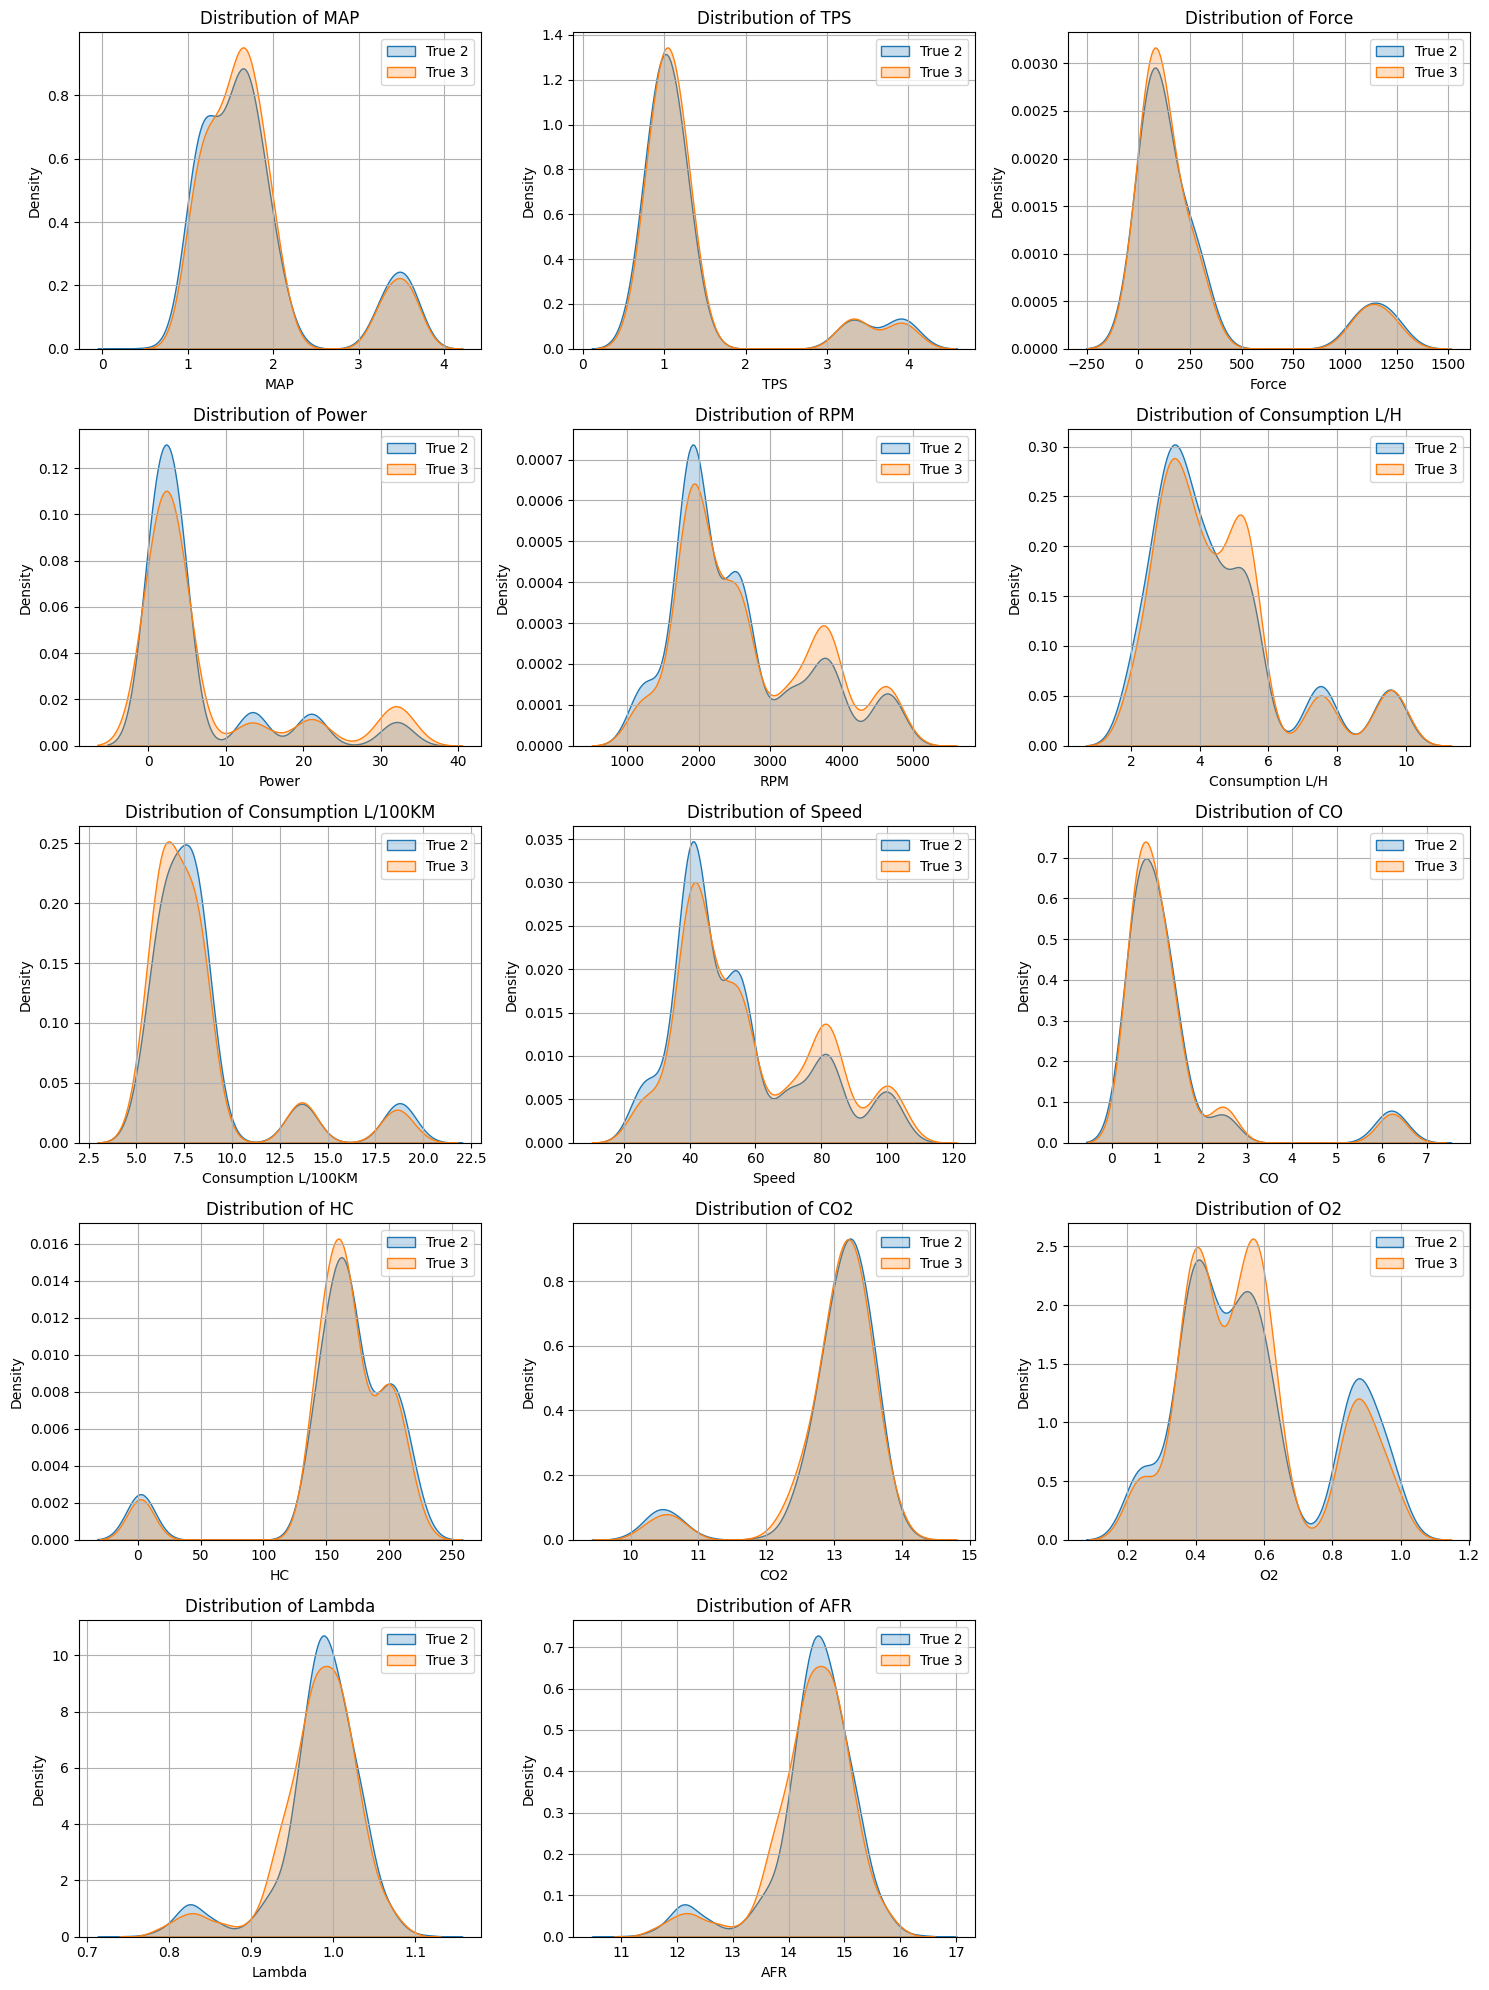

In [107]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

feature_cols = [col for col in df_conf_23.columns if col not in ['true', 'pred', 'conf_pred', 'conf_true']]

n = len(feature_cols)
cols = 3
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten()

for i, feature in enumerate(feature_cols):
    ax = axes[i]

    sns.kdeplot(df_conf_23[df_conf_23["true"] == 2][feature],
                label="True 2", fill=True, ax=ax)
    sns.kdeplot(df_conf_23[df_conf_23["true"] == 3][feature],
                label="True 3", fill=True, ax=ax)

    ax.set_title(f"Distribution of {feature}")
    ax.set_xlabel(feature)
    ax.grid(True)
    ax.legend()

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# 2 Level Classification

In [108]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

Level 1 Report (0,1,(2,3)):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       1.00      1.00      1.00      5800

    accuracy                           1.00     11200
   macro avg       1.00      1.00      1.00     11200
weighted avg       1.00      1.00      1.00     11200



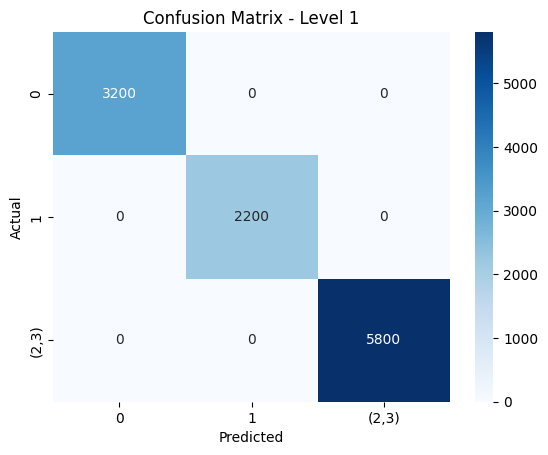

In [109]:
# level 1: classify 0, 1, and group (2,3)
def map_group(y):
    return np.array([cls if cls in [0,1] else 2 for cls in y])  # 0,1 stay, 2,3 -> 2

y_train_lvl1 = map_group(y_train)
y_test_lvl1 = map_group(y_test)

model_lvl1 = XGBClassifier(eval_metric='mlogloss', random_state=42)
model_lvl1.fit(X_train, y_train_lvl1)

preds_lvl1 = model_lvl1.predict(X_test)

print("Level 1 Report (0,1,(2,3)):")
print(classification_report(y_test_lvl1, preds_lvl1))
cm = confusion_matrix(y_test_lvl1, preds_lvl1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0","1","(2,3)"], yticklabels=["0","1","(2,3)"])
plt.title("Confusion Matrix - Level 1")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Level 2 Report (2 vs 3):
              precision    recall  f1-score   support

           2       0.53      0.54      0.54      3000
           3       0.50      0.50      0.50      2800

    accuracy                           0.52      5800
   macro avg       0.52      0.52      0.52      5800
weighted avg       0.52      0.52      0.52      5800



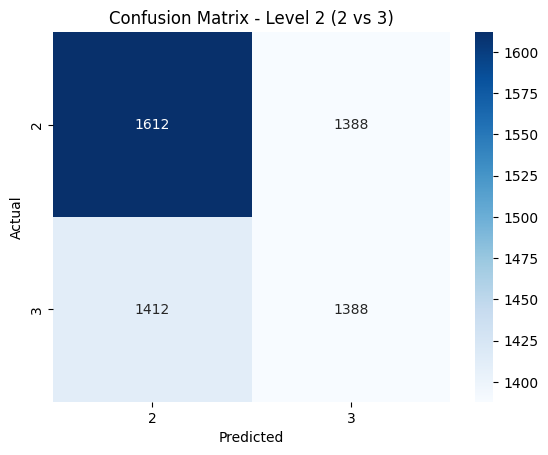

In [110]:
# level 2: classify 2 vs 3 (only on group B)
mask_train_B = np.isin(y_train, [2,3])
mask_test_B = np.isin(y_test, [2,3])
X_train_B, y_train_B = X_train[mask_train_B], y_train[mask_train_B]
X_test_B, y_test_B = X_test[mask_test_B], y_test[mask_test_B]

# remap 2 -> 0, 3 -> 1
y_train_B_mapped = np.where(y_train_B == 2, 0, 1)
y_test_B_mapped  = np.where(y_test_B == 2, 0, 1)

model_lvl2 = XGBClassifier(eval_metric='mlogloss', random_state=42)
model_lvl2.fit(X_train_B, y_train_B_mapped)

preds_lvl2 = model_lvl2.predict(X_test_B)

# map back 0->2, 1->3
preds_lvl2_back = np.where(preds_lvl2 == 0, 2, 3)

print("\nLevel 2 Report (2 vs 3):")
print(classification_report(y_test_B, preds_lvl2_back))
cm = confusion_matrix(y_test_B, preds_lvl2_back)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["2","3"], yticklabels=["2","3"])
plt.title("Confusion Matrix - Level 2 (2 vs 3)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Final Report (0,1,2,3):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.53      0.54      0.54      3000
           3       0.50      0.50      0.50      2800

    accuracy                           0.75     11200
   macro avg       0.76      0.76      0.76     11200
weighted avg       0.75      0.75      0.75     11200



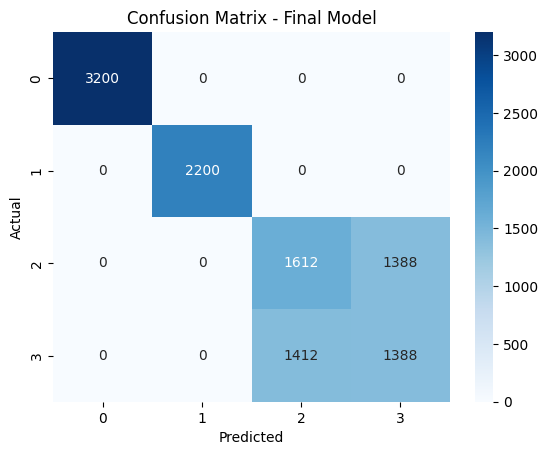

Overall Accuracy: 0.75


In [111]:
# final predictions
def hierarchical_predict(X):
    preds_lvl1 = model_lvl1.predict(X)
    final_preds = []
    for i, p in enumerate(preds_lvl1):
        if p in [0,1]:   # direct class
            final_preds.append(p)
        else:            # group (2,3)
            pred_b = model_lvl2.predict(X[i].reshape(1,-1))[0]
            final_preds.append(2 if pred_b == 0 else 3)  # map back
    return np.array(final_preds)

final_preds = hierarchical_predict(X_test)

print("\nFinal Report (0,1,2,3):")
print(classification_report(y_test, final_preds))
cm = confusion_matrix(y_test, final_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0","1","2","3"], yticklabels=["0","1","2","3"])
plt.title("Confusion Matrix - Final Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

acc = accuracy_score(y_test, final_preds)
print("Overall Accuracy:", acc)

# Uncertainty-Aware Hierarchical Fault Classification

In [112]:
X = df.drop("Fault", axis=1).values
y = df["Fault"].values

scaler = MinMaxScaler()

X_scaled = scaler.fit_transform(X)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [113]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=42
)

# Level-1 Model (0,1,(2,3))

In [114]:
def map_group(y):
    return np.array([cls if cls in [0,1] else 2 for cls in y])

In [115]:
y_train_lvl1 = map_group(y_train)

y_test_lvl1 = map_group(y_test)

In [116]:
# Train model

model_lvl1 = XGBClassifier(eval_metric='mlogloss', random_state=42)

model_lvl1.fit(X_train, y_train_lvl1)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Level-2 Model (2 vs 3)

In [117]:
# Extract subset
mask_train_B = np.isin(y_train, [2,3])
mask_test_B = np.isin(y_test, [2,3])

X_train_B, y_train_B = X_train[mask_train_B], y_train[mask_train_B]
X_test_B, y_test_B = X_test[mask_test_B], y_test[mask_test_B]

In [118]:
# Train model
model_lvl2 = XGBClassifier(eval_metric='mlogloss', random_state=42)

model_lvl2.fit(X_train_B, y_train_B_mapped)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

# Trapezoidal Fuzzy Decision Function

In [119]:
def trapezoidal_fuzzy_decision(prob, a=0.3, b=0.4, c=0.6, d=0.7):
    """
    Trapezoidal fuzzy-based decision for 2 vs 3 classification.
    a,b,c,d define fuzzy region boundaries.
    """
    if prob <= a:
        return "Class 3 (Confident)"
    elif a < prob <= b:
        return "Unsure zone (Leaning 3)"
    elif b < prob <= c:
        return "Ambiguous"
    elif c < prob <= d:
        return "Unsure zone (Leaning 2)"
    else:
        return "Class 2 (Confident)"

# Hierarchical Prediction with Fuzzy Logic

In [120]:
def hierarchical_predict_trapezoidal(X, a=0.3, b=0.4, c=0.6, d=0.7):
    lvl1_preds = model_lvl1.predict(X)
    final_preds = []
    fuzzy_labels = []

    for i, p in enumerate(lvl1_preds):
        if p in [0,1]:
            final_preds.append(p)
            fuzzy_labels.append(f"Class {p}")
        else:
            p2 = model_lvl2.predict_proba(X[i].reshape(1,-1))[0]
            prob_class2 = p2[0]  # probability of class 2 (mapped 0)
            zone = trapezoidal_fuzzy_decision(prob_class2, a, b, c, d)
            fuzzy_labels.append(zone)

            if "3" in zone:
                final_preds.append(3)
            elif "2" in zone:
                final_preds.append(2)
            else:
                final_preds.append(4)  # Ambiguous
    return np.array(final_preds), fuzzy_labels

# Apply Hierarchical Fuzzy Model

In [121]:
final_preds_trap, fuzzy_zones = hierarchical_predict_trapezoidal(X_test)

# Full Classification Report

In [122]:
print("\nClassification Report (0,1,2,3,Ambiguous):")
print(classification_report(y_test, final_preds_trap, labels=[0,1,2,3,4]))


Classification Report (0,1,2,3,Ambiguous):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.55      0.23      0.33      3000
           3       0.49      0.18      0.27      2800
           4       0.00      0.00      0.00         0

    accuracy                           0.59     11200
   macro avg       0.61      0.48      0.52     11200
weighted avg       0.75      0.59      0.64     11200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


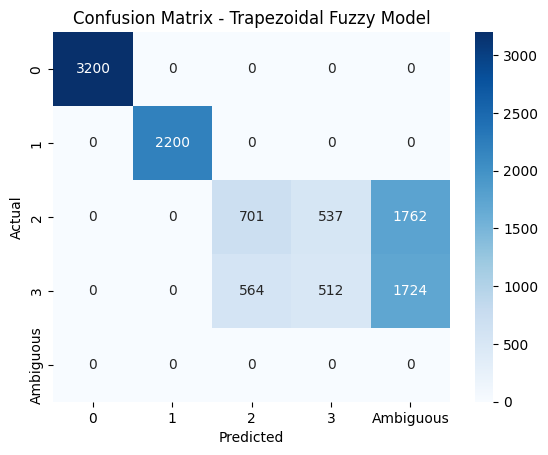

In [123]:
cm = confusion_matrix(y_test, final_preds_trap, labels=[0,1,2,3,4])

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["0","1","2","3","Ambiguous"],
            yticklabels=["0","1","2","3","Ambiguous"])

plt.title("Confusion Matrix - Trapezoidal Fuzzy Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Ambiguity Statistics

In [124]:
ambiguous_count = np.sum(final_preds_trap == 4)

ambiguous_ratio = ambiguous_count / len(final_preds_trap)

print(f"Ambiguous samples: {ambiguous_count} ({ambiguous_ratio*100:.2f}%)")

Ambiguous samples: 3486 (31.13%)


# Accuracy on Confident Predictions

In [125]:
mask_confident = final_preds_trap != 4

confident_acc = accuracy_score(
    y_test[mask_confident],
    final_preds_trap[mask_confident]
)

print("Accuracy on confident samples:", confident_acc)

Accuracy on confident samples: 0.857272491573762


# Confusion Matrix (Confident Only)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3200
           1       1.00      1.00      1.00      2200
           2       0.55      0.57      0.56      1238
           3       0.49      0.48      0.48      1076

    accuracy                           0.86      7714
   macro avg       0.76      0.76      0.76      7714
weighted avg       0.86      0.86      0.86      7714



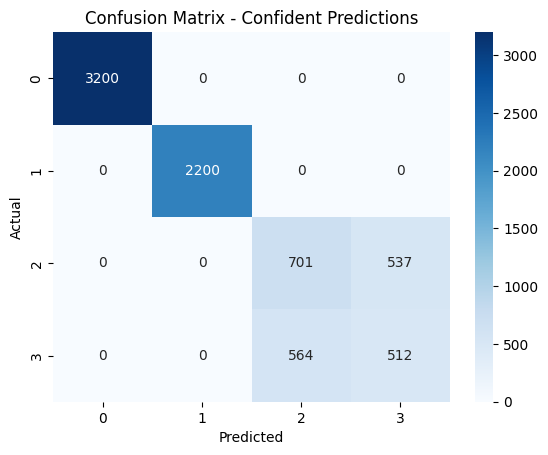

In [126]:
y_test_conf = y_test[mask_confident]

preds_conf = final_preds_trap[mask_confident]

print(classification_report(y_test_conf, preds_conf))

cm_conf = confusion_matrix(y_test_conf, preds_conf)

sns.heatmap(cm_conf, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix - Confident Predictions")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

# Plot Trapezoidal Membership Function

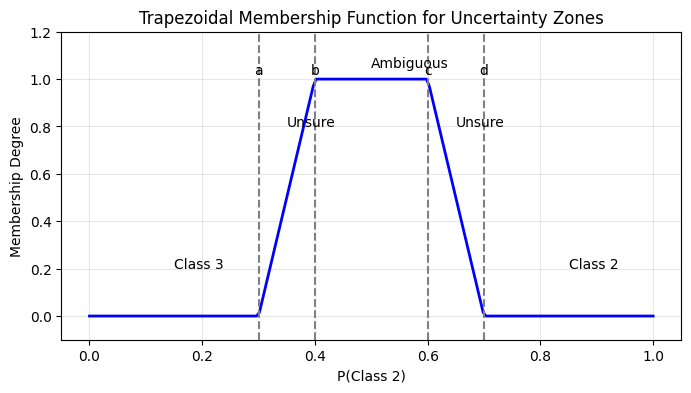

In [127]:
def plot_trapezoidal_mf(a=0.3, b=0.4, c=0.6, d=0.7):
    x = np.linspace(0, 1, 200)
    y = np.piecewise(x, [
        (x <= a),
        (a < x) & (x <= b),
        (b < x) & (x <= c),
        (c < x) & (x <= d),
        (x > d)
    ], [
        lambda x: 0,                  # class 3 zone
        lambda x: (x - a) / (b - a),  # false rise
        lambda x: 1,                  # ambiguous plateau
        lambda x: (d - x) / (d - c),  # unsure fall
        lambda x: 0                   # class 2 zone
    ])

    plt.figure(figsize=(8,4))
    plt.plot(x, y, color='blue', linewidth=2)
    plt.title("Trapezoidal Membership Function for Uncertainty Zones")
    plt.xlabel("P(Class 2)")
    plt.ylabel("Membership Degree")
    plt.axvline(a, color='gray', linestyle='--'); plt.text(a, 1.02, "a", ha='center')
    plt.axvline(b, color='gray', linestyle='--'); plt.text(b, 1.02, "b", ha='center')
    plt.axvline(c, color='gray', linestyle='--'); plt.text(c, 1.02, "c", ha='center')
    plt.axvline(d, color='gray', linestyle='--'); plt.text(d, 1.02, "d", ha='center')

    plt.text(0.15, 0.2, "Class 3", fontsize=10)
    plt.text(0.35, 0.8, "Unsure", fontsize=10)
    plt.text(0.5, 1.05, "Ambiguous", fontsize=10)
    plt.text(0.65, 0.8, "Unsure", fontsize=10)
    plt.text(0.85, 0.2, "Class 2", fontsize=10)
    plt.ylim(-0.1, 1.2)
    plt.grid(alpha=0.3)
    plt.show()

plot_trapezoidal_mf()

# Example Outputs

In [128]:
sample_probs = [0.1, 0.35, 0.45, 0.55, 0.65, 0.9]
print("\nExample Trapezoidal Fuzzy Outputs:")
for p in sample_probs:
    print(f"P(Class2)={p:.2f} → {trapezoidal_fuzzy_decision(p)}")


Example Trapezoidal Fuzzy Outputs:
P(Class2)=0.10 → Class 3 (Confident)
P(Class2)=0.35 → Unsure zone (Leaning 3)
P(Class2)=0.45 → Ambiguous
P(Class2)=0.55 → Ambiguous
P(Class2)=0.65 → Unsure zone (Leaning 2)
P(Class2)=0.90 → Class 2 (Confident)


# Tabular Example Outputs

In [129]:

num_samples = 10
sample_indices = np.random.choice(len(X_test), num_samples, replace=False)

records = []

for idx in sample_indices:
    x_sample = X_test[idx].reshape(1, -1)
    true_label = y_test[idx]
    lvl1_pred = model_lvl1.predict(x_sample)[0]

    if lvl1_pred in [0, 1]:
        final_pred = lvl1_pred
        fuzzy_zone = f"Class {lvl1_pred} (Confident)"
        prob_class2, prob_class3 = np.nan, np.nan
    else:
        p2 = model_lvl2.predict_proba(x_sample)[0]
        prob_class2, prob_class3 = p2[0], p2[1]
        fuzzy_zone = trapezoidal_fuzzy_decision(prob_class2)

        if "3" in fuzzy_zone:
            final_pred = 3
        elif "2" in fuzzy_zone:
            final_pred = 2
        else:
            final_pred = 4  # Ambiguous

    records.append({
        "True Label": true_label,
        "Predicted": final_pred,
        "Prob(Class2)": round(prob_class2, 3),
        "Prob(Class3)": round(prob_class3, 3),
        "Fuzzy Zone": fuzzy_zone
    })

results_df = pd.DataFrame(records)
print("Example Samples with Fuzzy Decisions-")
display(results_df.style.hide(axis="index"))

Example Samples with Fuzzy Decisions-


True Label,Predicted,Prob(Class2),Prob(Class3),Fuzzy Zone
3,2,0.608000,0.392000,Unsure zone (Leaning 2)
2,3,0.369000,0.631000,Unsure zone (Leaning 3)
3,4,0.451000,0.549000,Ambiguous
2,4,0.467000,0.533000,Ambiguous
3,2,0.679000,0.321000,Unsure zone (Leaning 2)
3,3,0.388000,0.612000,Unsure zone (Leaning 3)
0,0,nan,nan,Class 0 (Confident)
2,2,0.625000,0.375000,Unsure zone (Leaning 2)
2,4,0.504000,0.496000,Ambiguous
1,1,nan,nan,Class 1 (Confident)


# Experiment at different seed results

In [130]:
def run_experiment(random_state):
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_encoded,
        test_size=0.2,
        stratify=y_encoded,
        random_state=random_state
    )

    # -------- Level 1 --------
    y_train_lvl1 = map_group(y_train)
    model_lvl1 = XGBClassifier(
        eval_metric='mlogloss',
        random_state=random_state
    )
    model_lvl1.fit(X_train, y_train_lvl1)

    # -------- Level 2 --------
    mask_train_B = np.isin(y_train, [2,3])
    X_train_B = X_train[mask_train_B]
    y_train_B = np.where(y_train[mask_train_B] == 2, 0, 1)

    model_lvl2 = XGBClassifier(
        eval_metric='mlogloss',
        random_state=random_state
    )
    model_lvl2.fit(X_train_B, y_train_B)

    # -------- Prediction --------
    final_preds, _ = hierarchical_predict_trapezoidal(X_test)

    # Confident accuracy
    mask_conf = final_preds != 4
    acc = accuracy_score(y_test[mask_conf], final_preds[mask_conf])
    amb_ratio = np.mean(final_preds == 4)

    return acc, amb_ratio


In [131]:
acc_list = []
amb_list = []

for seed in [0, 1, 2, 3, 4]:
    acc, amb = run_experiment(seed)
    acc_list.append(acc)
    amb_list.append(amb)

print("Confident Accuracy: {:.4f} ± {:.4f}".format(
    np.mean(acc_list), np.std(acc_list)
))
print("Ambiguous Ratio: {:.2f}% ± {:.2f}%".format(
    np.mean(amb_list)*100, np.std(amb_list)*100
))

Confident Accuracy: 0.9614 ± 0.0013
Ambiguous Ratio: 27.26% ± 0.07%
